## Idealised case of known noise law $a N^b $

Residual-fit sigma(N): 0.104340 * N^1.265414

Running initialization 123

[seed=123] epoch=    0 loss=491.982239 nll=491.982239 mono=0.000000 x0=0.7329 a=0.1002 b=1.0013
[seed=123] epoch=  500 loss=-9.896493 nll=-9.896493 mono=0.000000 x0=0.4590 a=0.1598 b=0.7200
[seed=123] epoch= 1000 loss=-27.978247 nll=-27.978247 mono=0.000000 x0=0.3209 a=0.1866 b=0.5788
[seed=123] epoch= 1500 loss=-33.279072 nll=-33.279072 mono=0.000000 x0=0.2363 a=0.1914 b=0.5185
[seed=123] epoch= 2000 loss=-36.782112 nll=-36.782112 mono=0.000000 x0=0.1755 a=0.1817 b=0.4992
[seed=123] epoch= 2500 loss=-42.725471 nll=-42.725471 mono=0.000000 x0=0.1278 a=0.1606 b=0.5238
[seed=123] epoch= 3000 loss=-52.183346 nll=-52.183346 mono=0.000000 x0=0.1007 a=0.1212 b=0.6892
[seed=123] epoch= 3500 loss=-56.598423 nll=-56.598423 mono=0.000000 x0=0.0854 a=0.0997 b=0.9896
[seed=123] epoch= 4000 loss=-57.782024 nll=-57.782024 mono=0.000000 x0=0.0864 a=0.0992 b=1.2495
[seed=123] epoch= 4500 loss=-58.131409 nll=-58.131409 mono=0.000

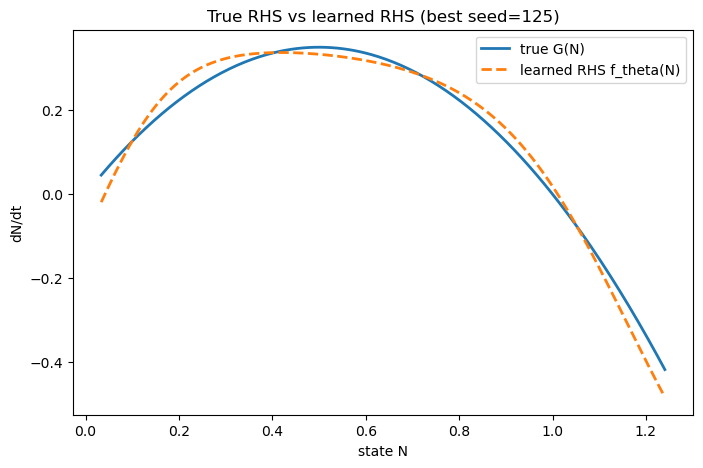

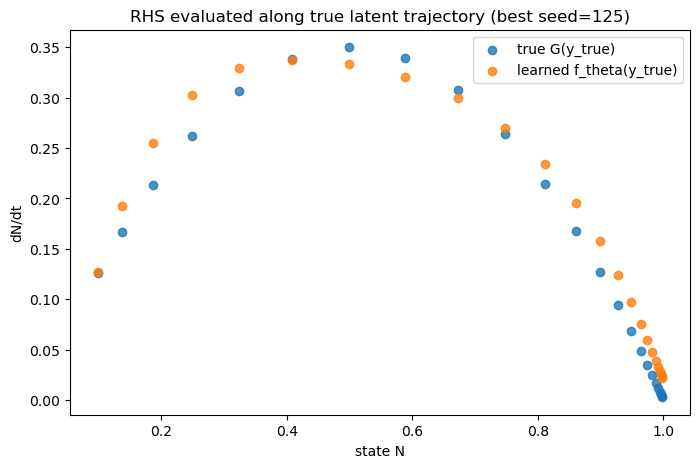

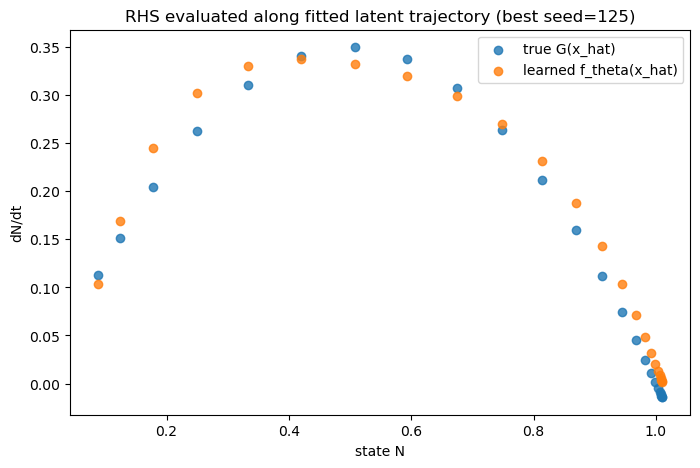

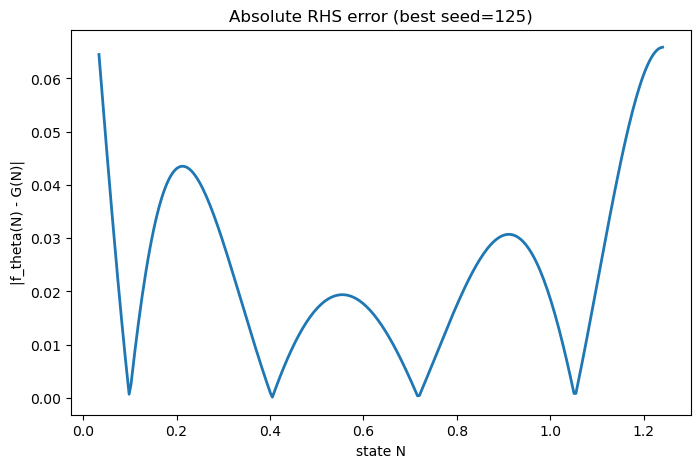

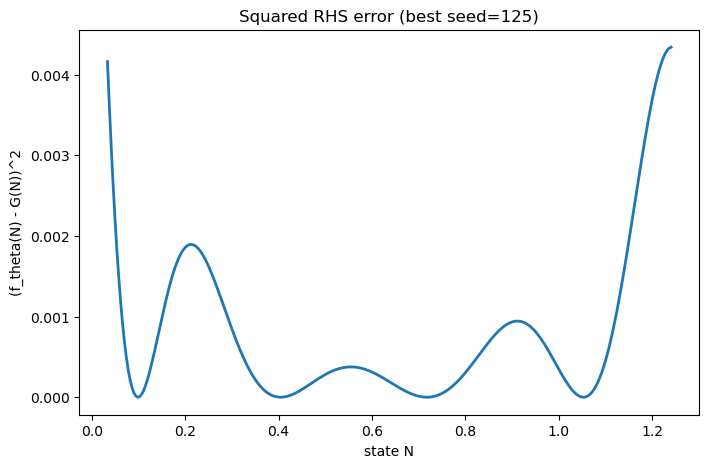

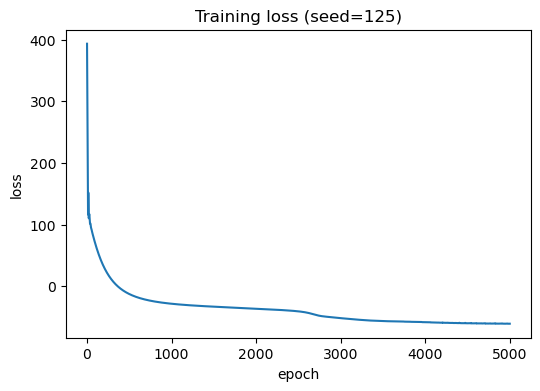

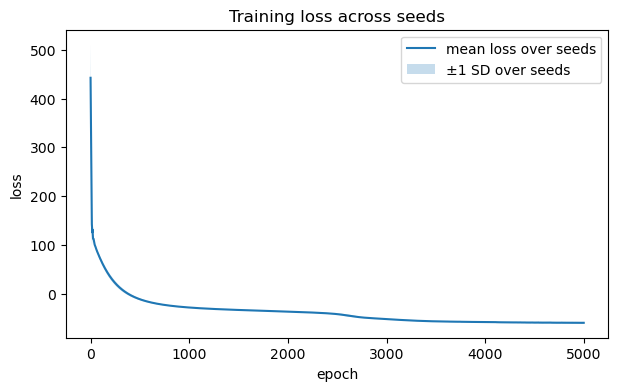

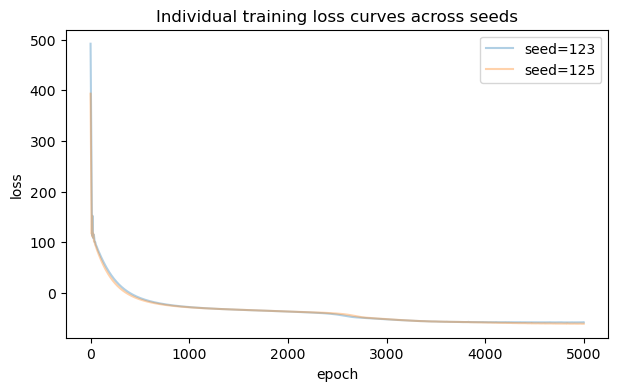

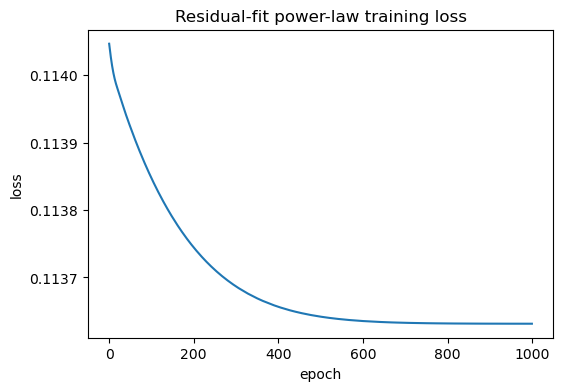

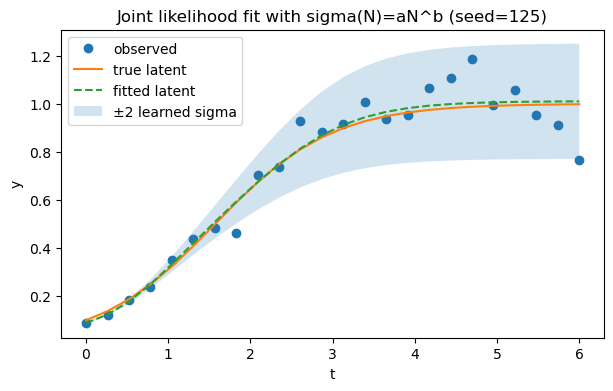

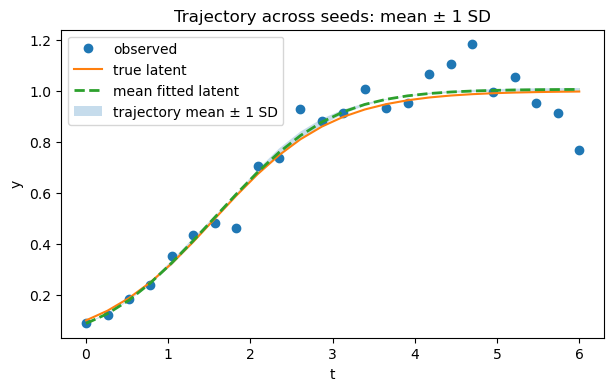

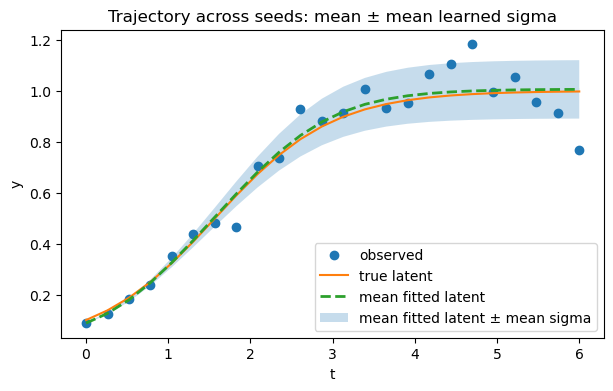

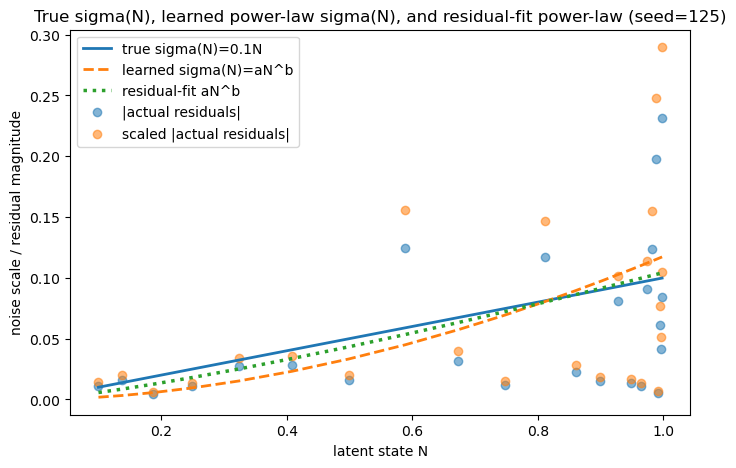

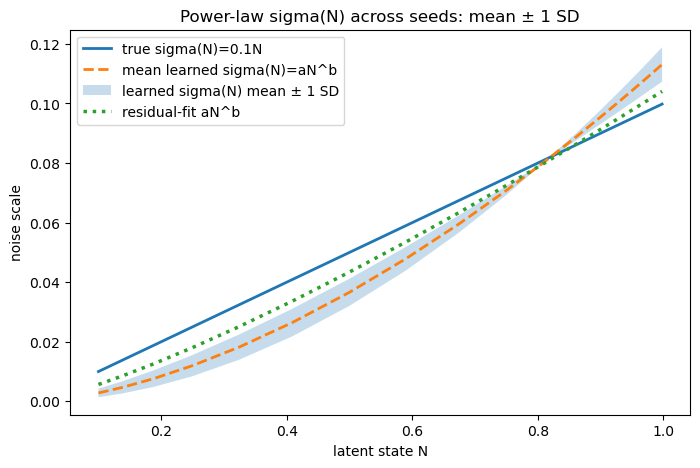

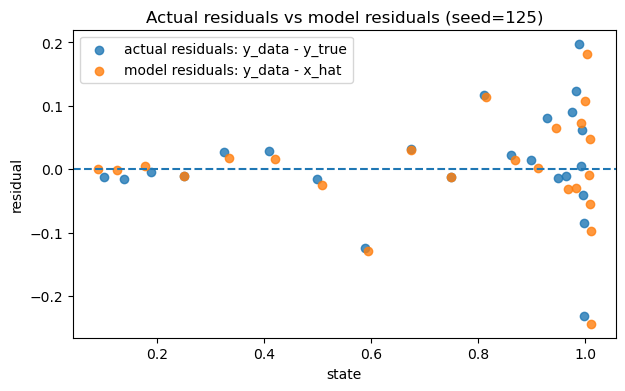

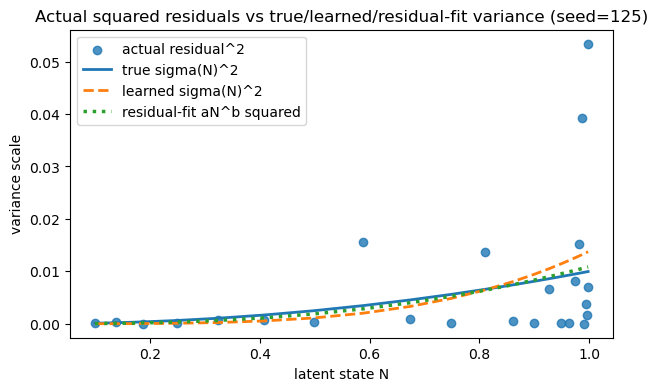

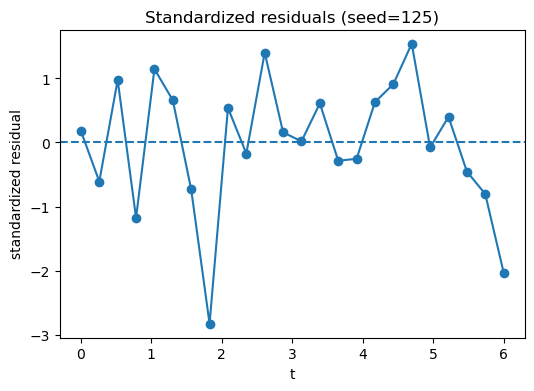

In [4]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 3. Neural RHS model: x' = f_theta(x)
# ============================================================
class DriftNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, t, x):
        return self.net(x)


# ============================================================
# 4. Parametric power-law model: sigma(x) = a * x^b
#    Used both for learned sigma(N) and residual-fit sigma(N)
# ============================================================
class PowerLawSigma(nn.Module):
    def __init__(self, a_init=0.1, b_init=1.0):
        super().__init__()

        a_init_u = np.log(np.exp(a_init) - 1.0) if a_init > 1e-8 else -10.0
        b_init_u = np.log(np.exp(b_init) - 1.0) if b_init > 1e-8 else -10.0

        self.a_unconstrained = nn.Parameter(torch.tensor([a_init_u], dtype=torch.float32))
        self.b_unconstrained = nn.Parameter(torch.tensor([b_init_u], dtype=torch.float32))

    def a(self):
        return torch.nn.functional.softplus(self.a_unconstrained) + 1e-8

    def b(self):
        return torch.nn.functional.softplus(self.b_unconstrained) + 1e-8

    def sigma_only(self, x):
        x_safe = torch.where(x > 0.0, x, torch.full_like(x, 1e-8))
        return self.a() * (x_safe ** self.b())

    def forward(self, x):
        sigma = self.sigma_only(x)
        log_sigma = torch.log(sigma)
        return sigma, log_sigma


# ============================================================
# 5. Full joint model with power-law sigma
# ============================================================
class JointNeuralLikelihoodModel(nn.Module):
    def __init__(self, hidden_drift=32, x0_init=0.05, sigma_a_init=0.1, sigma_b_init=1.0):
        super().__init__()
        self.drift = DriftNet(hidden=hidden_drift)
        self.noise = PowerLawSigma(a_init=sigma_a_init, b_init=sigma_b_init)
        self.x0_unconstrained = nn.Parameter(torch.tensor([[x0_init]], dtype=torch.float32))

    def x0(self):
        return torch.nn.functional.softplus(self.x0_unconstrained)

    def latent_traj(self, t):
        x0 = self.x0()
        x_path = odeint_rk4(self.drift, x0, t.squeeze()).squeeze(1)
        return x_path

    def nll(self, t, y_obs):
        x_path = self.latent_traj(t)
        sigma, log_sigma = self.noise(x_path)

        resid = y_obs - x_path
        nll_pointwise = 0.5 * (resid / sigma) ** 2 + log_sigma
        nll = nll_pointwise.sum()

        return nll, {
            "x_path": x_path,
            "sigma": sigma,
            "log_sigma": log_sigma,
            "resid": resid,
            "nll_pointwise": nll_pointwise,
        }


# ============================================================
# 6. Regularization helpers
# ============================================================
def smoothness_penalty_on_path(x_path):
    if len(x_path) < 3:
        return torch.tensor(0.0, device=x_path.device)
    second_diff = x_path[2:] - 2.0 * x_path[1:-1] + x_path[:-2]
    return (second_diff ** 2).sum()

def weight_decay(model):
    reg = 0.0
    for p in model.parameters():
        reg = reg + (p ** 2).sum()
    return reg

def monotonicity_penalty_sigma(x_ref, sigma_ref):
    x_flat = x_ref.squeeze(-1)
    sigma_flat = sigma_ref.squeeze(-1)

    idx = torch.argsort(x_flat)
    sigma_sorted = sigma_flat[idx]
    dsigma = sigma_sorted[1:] - sigma_sorted[:-1]
    return torch.relu(-dsigma).sum()

def sigma_anchor_penalty(sigma):
    return ((sigma - sigma.mean()) ** 2).sum()


# ============================================================
# 7. Fit power-law to true residual magnitudes
#    We fit to scaled |residual| so target is comparable to sigma
#    under a Gaussian law: E|Z| = sqrt(2/pi)
# ============================================================
def fit_residual_powerlaw(
    x_ref,
    scaled_abs_resid,
    max_epochs=4000,
    lr=1e-2,
    a_init=0.1,
    b_init=1.0,
):
    proxy_model = PowerLawSigma(a_init=a_init, b_init=b_init).to(device)
    optimizer = torch.optim.Adam(proxy_model.parameters(), lr=lr)

    best_state = None
    best_loss = float("inf")
    loss_history = []

    for epoch in range(max_epochs):
        optimizer.zero_grad()

        pred = proxy_model.sigma_only(x_ref)
        data_loss = ((pred - scaled_abs_resid) ** 2).sum()
        reg = 1e-6 * (
            (proxy_model.a_unconstrained ** 2).sum()
            + (proxy_model.b_unconstrained ** 2).sum()
        )
        mono = 1.0 * monotonicity_penalty_sigma(x_ref, pred)

        loss = data_loss + reg + mono
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = copy.deepcopy(proxy_model.state_dict())

    if best_state is not None:
        proxy_model.load_state_dict(best_state)

    return proxy_model, loss_history


# ============================================================
# 8. Train + evaluate one run
# ============================================================
def train_and_evaluate(
    seed,
    residual_proxy_model,
    max_epochs_model=5000,
    spike_delta_abs=10.0,
    spike_delta_rel=5.0,
    patience_after_best=200,
    grad_norm_spike_threshold=1e6,
    x_path_abs_threshold=10.0,
    sigma_abs_threshold=10.0,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    y_obs = y_data.detach().clone()

    model = JointNeuralLikelihoodModel(
        hidden_drift=8,
        x0_init=0.08,
        sigma_a_init=0.1,
        sigma_b_init=1.0,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

    loss_history = []
    best_state = None
    best_loss = float("inf")
    terminated_early = False
    termination_reason = "completed"
    best_epoch = -1

    for epoch in range(max_epochs_model):
        optimizer.zero_grad()

        nll, aux = model.nll(t_obs, y_obs)
        x_path = aux["x_path"]
        sigma = aux["sigma"]

        # Optional regularizers
        # reg_path = 1e-2 * smoothness_penalty_on_path(x_path)
        # reg_w = 1e-6 * weight_decay(model)
        # reg_sigma = 1e-4 * sigma_anchor_penalty(sigma)
        reg_mono = 1.0 * monotonicity_penalty_sigma(x_path.detach(), sigma)

        loss = nll + reg_mono

        if not torch.isfinite(loss):
            terminated_early = True
            termination_reason = f"non-finite loss at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(x_path).all():
            terminated_early = True
            termination_reason = f"non-finite latent trajectory at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(sigma).all():
            terminated_early = True
            termination_reason = f"non-finite sigma at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        max_abs_x = x_path.abs().max().item()
        max_sigma = sigma.max().item()

        if max_abs_x > x_path_abs_threshold:
            terminated_early = True
            termination_reason = (
                f"latent trajectory exceeded threshold at epoch {epoch} "
                f"(max |x| = {max_abs_x:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if max_sigma > sigma_abs_threshold:
            terminated_early = True
            termination_reason = (
                f"sigma exceeded threshold at epoch {epoch} "
                f"(max sigma = {max_sigma:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        loss.backward()

        total_grad_sq = 0.0
        grad_is_finite = True
        for p in model.parameters():
            if p.grad is not None:
                if not torch.isfinite(p.grad).all():
                    grad_is_finite = False
                    break
                total_grad_sq += (p.grad ** 2).sum().item()

        grad_norm = np.sqrt(total_grad_sq) if grad_is_finite else np.inf

        if not np.isfinite(grad_norm):
            terminated_early = True
            termination_reason = f"non-finite gradient norm at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if grad_norm > grad_norm_spike_threshold:
            terminated_early = True
            termination_reason = (
                f"gradient spike at epoch {epoch} "
                f"(grad_norm = {grad_norm:.6e})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        current_loss = loss.item()
        loss_history.append(current_loss)

        if current_loss < best_loss:
            best_loss = current_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        elif best_loss < float("inf"):
            loss_jump = current_loss - best_loss
            relative_jump = loss_jump / max(abs(best_loss), 1.0)

            if loss_jump > spike_delta_abs and relative_jump > spike_delta_rel:
                print("best loss", best_loss)
                print("loss jump", loss_jump)
                print("relative jump", relative_jump)

                terminated_early = True
                termination_reason = (
                    f"loss spike at epoch {epoch} "
                    f"(loss = {current_loss:.6e}, best_loss = {best_loss:.6e}, "
                    f"jump = {loss_jump:.6e}, rel_jump = {relative_jump:.6e})"
                )
                print(f"[seed={seed}] Terminating: {termination_reason}")
                break

        if best_epoch >= 0 and (epoch - best_epoch) > patience_after_best:
            if current_loss > best_loss + 5.0 * max(abs(best_loss), 1.0):
                terminated_early = True
                termination_reason = (
                    f"sustained deterioration after best epoch "
                    f"(epoch = {epoch}, best_epoch = {best_epoch}, "
                    f"loss = {current_loss:.6e}, best_loss = {best_loss:.6e})"
                )
                print(f"[seed={seed}] Terminating: {termination_reason}")
                break

        optimizer.step()

        if epoch % 500 == 0:
            print(
                f"[seed={seed}] "
                f"epoch={epoch:5d} "
                f"loss={loss.item():.6f} "
                f"nll={nll.item():.6f} "
                f"mono={reg_mono.item():.6f} "
                f"x0={model.x0().item():.4f} "
                f"a={model.noise.a().item():.4f} "
                f"b={model.noise.b().item():.4f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    # ============================================================
    # 9. Evaluate fitted objects
    # ============================================================
    with torch.no_grad():
        nll, aux = model.nll(t_obs, y_obs)

        x_hat = aux["x_path"]
        sigma_hat = aux["sigma"]
        resid = aux["resid"]
        z_hat = resid / sigma_hat

        sigma_true_vals = 0.1 * y_true
        sigma_hat_on_true, _ = model.noise(y_true)
        residual_fit_sigma_on_true = residual_proxy_model(y_true)[0]

        idx_true = torch.argsort(y_true.squeeze())
        N_true_sorted = y_true[idx_true].squeeze()
        sigma_true_sorted = sigma_true_vals[idx_true].squeeze()
        sigma_hat_true_sorted = sigma_hat_on_true[idx_true].squeeze()
        residual_fit_sigma_sorted = residual_fit_sigma_on_true[idx_true].squeeze()

        actual_resid = y_data - y_true
        actual_abs_resid = actual_resid.abs()
        scaled_abs_resid = actual_abs_resid * np.sqrt(np.pi / 2.0)
        actual_abs_resid_sorted = actual_abs_resid[idx_true].squeeze()
        scaled_abs_resid_sorted = scaled_abs_resid[idx_true].squeeze()

    return {
        "seed": seed,
        "model": model,
        "loss_history": loss_history,
        "x_hat": x_hat.detach().clone(),
        "sigma_hat": sigma_hat.detach().clone(),
        "resid": resid.detach().clone(),
        "z_hat": z_hat.detach().clone(),
        "sigma_true_vals": sigma_true_vals.detach().clone(),
        "sigma_hat_on_true": sigma_hat_on_true.detach().clone(),
        "residual_fit_sigma_on_true": residual_fit_sigma_on_true.detach().clone(),
        "actual_resid": actual_resid.detach().clone(),
        "actual_abs_resid": actual_abs_resid.detach().clone(),
        "scaled_abs_resid": scaled_abs_resid.detach().clone(),
        "N_true_sorted": N_true_sorted.detach().clone(),
        "sigma_true_sorted": sigma_true_sorted.detach().clone(),
        "sigma_hat_true_sorted": sigma_hat_true_sorted.detach().clone(),
        "residual_fit_sigma_sorted": residual_fit_sigma_sorted.detach().clone(),
        "actual_abs_resid_sorted": actual_abs_resid_sorted.detach().clone(),
        "scaled_abs_resid_sorted": scaled_abs_resid_sorted.detach().clone(),
        "fitted_a": model.noise.a().item(),
        "fitted_b": model.noise.b().item(),
        "terminated_early": terminated_early,
        "termination_reason": termination_reason,
        "best_loss": best_loss,
        "best_epoch": best_epoch,
    }


# ============================================================
# 10. Fit the separate a N^b model to the true residuals once
# ============================================================
with torch.no_grad():
    actual_resid_global = y_data - y_true
    actual_abs_resid_global = actual_resid_global.abs()
    scaled_abs_resid_global = actual_abs_resid_global * np.sqrt(np.pi / 2.0)

residual_proxy_model, residual_proxy_loss_history = fit_residual_powerlaw(
    x_ref=y_true,
    scaled_abs_resid=scaled_abs_resid_global,
    max_epochs=1000,
    lr=1e-3,
    a_init=0.10,
    b_init=1.0,
)

print(
    "Residual-fit sigma(N): "
    f"{residual_proxy_model.a().item():.6f} * N^{residual_proxy_model.b().item():.6f}"
)


# ============================================================
# 11. Run over multiple initializations
# ============================================================
num_runs = 5
results = []

for seed in range(num_runs):
    seed += 123
    print("\n===============================")
    print(f"Running initialization {seed}")
    print("===============================\n")

    res = train_and_evaluate(seed, residual_proxy_model=residual_proxy_model)
    results.append(res)

    print(
        f"[seed={seed}] fitted sigma(N): "
        f"{res['fitted_a']:.6f} * N^{res['fitted_b']:.6f}"
    )
    print(
        f"[seed={seed}] status: "
        f"terminated_early={res['terminated_early']} "
        f"reason={res['termination_reason']}"
    )

valid_results = [r for r in results if len(r["loss_history"]) > 0]

if len(valid_results) == 0:
    raise RuntimeError("No valid runs completed any optimization steps.")

best_run_idx = int(np.argmin([r["best_loss"] for r in valid_results]))
best_res = valid_results[best_run_idx]

print("\n==========================================")
print(f"Using seed={best_res['seed']} for single-run diagnostic plots")
print("==========================================\n")


# ============================================================
# 12. Aggregate over seeds and retain best model info
# ============================================================
best_model = best_res["model"]

loss_history = best_res["loss_history"]
x_hat = best_res["x_hat"]
sigma_hat = best_res["sigma_hat"]
resid = best_res["resid"]
z_hat = best_res["z_hat"]
sigma_true_vals = best_res["sigma_true_vals"]
actual_resid = best_res["actual_resid"]
actual_abs_resid = best_res["actual_abs_resid"]
scaled_abs_resid = best_res["scaled_abs_resid"]
N_true_sorted = best_res["N_true_sorted"]
sigma_true_sorted = best_res["sigma_true_sorted"]
sigma_hat_true_sorted = best_res["sigma_hat_true_sorted"]
residual_fit_sigma_sorted = best_res["residual_fit_sigma_sorted"]

idx_true = torch.argsort(y_true.squeeze())

# trajectory stack: [num_valid_runs, T]
xhat_runs = torch.stack([r["x_hat"].squeeze() for r in valid_results], dim=0)
sigmahat_runs = torch.stack([r["sigma_hat"].squeeze() for r in valid_results], dim=0)

xhat_mean = xhat_runs.mean(dim=0)
xhat_sd = xhat_runs.std(dim=0, unbiased=True) if len(valid_results) > 1 else torch.zeros_like(xhat_mean)

sigmahat_mean_t = sigmahat_runs.mean(dim=0)
sigmahat_sd_t = sigmahat_runs.std(dim=0, unbiased=True) if len(valid_results) > 1 else torch.zeros_like(sigmahat_mean_t)

# sigma(N) stack on true latent states: [num_valid_runs, T]
sigma_runs = torch.stack([r["sigma_hat_on_true"].squeeze() for r in valid_results], dim=0)

sigma_mean = sigma_runs.mean(dim=0)
sigma_sd = sigma_runs.std(dim=0, unbiased=True) if len(valid_results) > 1 else torch.zeros_like(sigma_mean)

sigma_mean_sorted = sigma_mean[idx_true].squeeze()
sigma_sd_sorted = sigma_sd[idx_true].squeeze()

# fitted power-law parameters across seeds
a_vals = np.array([r["fitted_a"] for r in valid_results])
b_vals = np.array([r["fitted_b"] for r in valid_results])

print(f"mean fitted a over valid runs: {a_vals.mean():.6f} ± {a_vals.std(ddof=1) if len(a_vals) > 1 else 0.0:.6f}")
print(f"mean fitted b over valid runs: {b_vals.mean():.6f} ± {b_vals.std(ddof=1) if len(b_vals) > 1 else 0.0:.6f}")

# loss curves padded with NaN so terminated runs can still be plotted
max_len = max(len(r["loss_history"]) for r in valid_results)
loss_matrix = np.full((len(valid_results), max_len), np.nan, dtype=float)
for i, r in enumerate(valid_results):
    lh = np.asarray(r["loss_history"], dtype=float)
    loss_matrix[i, :len(lh)] = lh

loss_mean = np.nanmean(loss_matrix, axis=0)
loss_sd = np.nanstd(loss_matrix, axis=0, ddof=1) if len(valid_results) > 1 else np.zeros(max_len)
loss_epochs = np.arange(max_len)


# ============================================================
# 13. Plot learned RHS against the true G(N) for the best model
# ============================================================
with torch.no_grad():
    # Choose a grid that covers the relevant state range
    n_min = min(y_true.min().item(), x_hat.min().item(), y_data.min().item())
    n_max = max(y_true.max().item(), x_hat.max().item(), y_data.max().item())

    pad = 0.05 * (n_max - n_min + 1e-6)
    N_grid = torch.linspace(n_min - pad, n_max + pad, 300, device=device).view(-1, 1)

    G_true_grid = G_true(N_grid)
    G_learned_grid = best_model.drift(torch.tensor(0.0, device=device), N_grid)

    # Also evaluate at the true latent states and fitted latent states
    G_true_on_y_true = G_true(y_true)
    G_learned_on_y_true = best_model.drift(torch.tensor(0.0, device=device), y_true)

    G_true_on_x_hat = G_true(x_hat)
    G_learned_on_x_hat = best_model.drift(torch.tensor(0.0, device=device), x_hat)

    rhs_abs_err = (G_learned_grid - G_true_grid).abs()
    rhs_sq_err = (G_learned_grid - G_true_grid) ** 2

# Smooth curve comparison
plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    G_true_grid.cpu().numpy(),
    linewidth=2,
    label="true G(N)"
)
plt.plot(
    N_grid.cpu().numpy(),
    G_learned_grid.cpu().numpy(),
    "--",
    linewidth=2,
    label="learned RHS f_theta(N)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title(f"True RHS vs learned RHS (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Comparison at observed trajectory states
plt.figure(figsize=(8, 5))
plt.scatter(
    y_true.squeeze().cpu().numpy(),
    G_true_on_y_true.squeeze().cpu().numpy(),
    alpha=0.8,
    label="true G(y_true)"
)
plt.scatter(
    y_true.squeeze().cpu().numpy(),
    G_learned_on_y_true.squeeze().cpu().numpy(),
    alpha=0.8,
    label="learned f_theta(y_true)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title(f"RHS evaluated along true latent trajectory (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Comparison at fitted latent states
plt.figure(figsize=(8, 5))
plt.scatter(
    x_hat.squeeze().cpu().numpy(),
    G_true_on_x_hat.squeeze().cpu().numpy(),
    alpha=0.8,
    label="true G(x_hat)"
)
plt.scatter(
    x_hat.squeeze().cpu().numpy(),
    G_learned_on_x_hat.squeeze().cpu().numpy(),
    alpha=0.8,
    label="learned f_theta(x_hat)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title(f"RHS evaluated along fitted latent trajectory (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Pointwise error on the grid
plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    rhs_abs_err.cpu().numpy(),
    linewidth=2
)
plt.xlabel("state N")
plt.ylabel("|f_theta(N) - G(N)|")
plt.title(f"Absolute RHS error (best seed={best_res['seed']})")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    rhs_sq_err.cpu().numpy(),
    linewidth=2
)
plt.xlabel("state N")
plt.ylabel("(f_theta(N) - G(N))^2")
plt.title(f"Squared RHS error (best seed={best_res['seed']})")
plt.show()


# ============================================================
# 14. Plot diagnostics
# ============================================================

# Training loss: representative run
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title(f"Training loss (seed={best_res['seed']})")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

# Training loss over seeds: mean ± 1 SD
plt.figure(figsize=(7, 4))
plt.plot(loss_epochs, loss_mean, label="mean loss over seeds")
plt.fill_between(
    loss_epochs,
    loss_mean - loss_sd,
    loss_mean + loss_sd,
    alpha=0.25,
    label="±1 SD over seeds"
)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training loss across seeds")
plt.legend()
plt.show()

# Individual loss curves
plt.figure(figsize=(7, 4))
for r in valid_results:
    plt.plot(r["loss_history"], alpha=0.35, label=f"seed={r['seed']}")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Individual training loss curves across seeds")
plt.legend()
plt.show()

# Residual-fit power-law training loss
plt.figure(figsize=(6, 4))
plt.plot(residual_proxy_loss_history)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Residual-fit power-law training loss")
plt.show()

# Representative trajectory fit
plt.figure(figsize=(7, 4))
plt.plot(t_obs.cpu(), y_data.cpu(), "o", label="observed")
plt.plot(t_obs.cpu(), y_true.cpu(), "-", label="true latent")
plt.plot(t_obs.cpu(), x_hat.cpu(), "--", label="fitted latent")
plt.fill_between(
    t_obs.squeeze().cpu().numpy(),
    (x_hat - 2 * sigma_hat).squeeze().cpu().numpy(),
    (x_hat + 2 * sigma_hat).squeeze().cpu().numpy(),
    alpha=0.2,
    label="±2 learned sigma"
)
plt.legend()
plt.xlabel("t")
plt.ylabel("y")
plt.title(f"Joint likelihood fit with sigma(N)=aN^b (seed={best_res['seed']})")
plt.show()

# Trajectory over seeds: mean ± 1 SD
plt.figure(figsize=(7, 4))
plt.plot(t_obs.cpu(), y_data.cpu(), "o", label="observed")
plt.plot(t_obs.cpu(), y_true.cpu(), "-", label="true latent")
plt.plot(t_obs.cpu(), xhat_mean.cpu(), "--", linewidth=2, label="mean fitted latent")
plt.fill_between(
    t_obs.squeeze().cpu().numpy(),
    (xhat_mean - xhat_sd).cpu().numpy(),
    (xhat_mean + xhat_sd).cpu().numpy(),
    alpha=0.25,
    label="trajectory mean ± 1 SD"
)
plt.xlabel("t")
plt.ylabel("y")
plt.title("Trajectory across seeds: mean ± 1 SD")
plt.legend()
plt.show()

# Trajectory over seeds: mean ± mean sigma
plt.figure(figsize=(7, 4))
plt.plot(t_obs.cpu(), y_data.cpu(), "o", label="observed")
plt.plot(t_obs.cpu(), y_true.cpu(), "-", label="true latent")
plt.plot(t_obs.cpu(), xhat_mean.cpu(), "--", linewidth=2, label="mean fitted latent")
plt.fill_between(
    t_obs.squeeze().cpu().numpy(),
    (xhat_mean - sigmahat_mean_t).cpu().numpy(),
    (xhat_mean + sigmahat_mean_t).cpu().numpy(),
    alpha=0.25,
    label="mean fitted latent ± mean sigma"
)
plt.xlabel("t")
plt.ylabel("y")
plt.title("Trajectory across seeds: mean ± mean learned sigma")
plt.legend()
plt.show()

# Main sigma comparison plot: representative run
plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_hat_true_sorted.cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)=aN^b"
)
plt.plot(
    N_true_sorted.cpu(),
    residual_fit_sigma_sorted.cpu(),
    ":",
    linewidth=2.5,
    label="residual-fit aN^b"
)
plt.scatter(
    y_true.squeeze().cpu(),
    actual_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="|actual residuals|"
)
plt.scatter(
    y_true.squeeze().cpu(),
    scaled_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="scaled |actual residuals|"
)
plt.xlabel("latent state N")
plt.ylabel("noise scale / residual magnitude")
plt.title(f"True sigma(N), learned power-law sigma(N), and residual-fit power-law (seed={best_res['seed']})")
plt.legend()
plt.show()

# Sigma(N) across seeds: mean ± 1 SD, plus residual-fit power-law
plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_mean_sorted.cpu(),
    "--",
    linewidth=2,
    label="mean learned sigma(N)=aN^b"
)
plt.fill_between(
    N_true_sorted.cpu().numpy(),
    (sigma_mean_sorted - sigma_sd_sorted).cpu().numpy(),
    (sigma_mean_sorted + sigma_sd_sorted).cpu().numpy(),
    alpha=0.25,
    label="learned sigma(N) mean ± 1 SD"
)
plt.plot(
    N_true_sorted.cpu(),
    residual_fit_sigma_sorted.cpu(),
    ":",
    linewidth=2.5,
    label="residual-fit aN^b"
)
plt.xlabel("latent state N")
plt.ylabel("noise scale")
plt.title("Power-law sigma(N) across seeds: mean ± 1 SD")
plt.legend()
plt.show()

# Residuals: actual vs model residuals
plt.figure(figsize=(7, 4))
plt.axhline(0.0, linestyle="--")
plt.scatter(
    y_true.squeeze().cpu(),
    actual_resid.squeeze().cpu(),
    label="actual residuals: y_data - y_true",
    alpha=0.8
)
plt.scatter(
    x_hat.squeeze().cpu(),
    resid.squeeze().cpu(),
    label="model residuals: y_data - x_hat",
    alpha=0.8
)
plt.xlabel("state")
plt.ylabel("residual")
plt.title(f"Actual residuals vs model residuals (seed={best_res['seed']})")
plt.legend()
plt.show()

# Squared residuals vs variance curves
plt.figure(figsize=(7, 4))
plt.scatter(
    y_true.squeeze().cpu(),
    (actual_resid ** 2).squeeze().cpu(),
    alpha=0.8,
    label="actual residual^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_true_sorted ** 2).cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_hat_true_sorted ** 2).cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (residual_fit_sigma_sorted ** 2).cpu(),
    ":",
    linewidth=2.5,
    label="residual-fit aN^b squared"
)
plt.xlabel("latent state N")
plt.ylabel("variance scale")
plt.title(f"Actual squared residuals vs true/learned/residual-fit variance (seed={best_res['seed']})")
plt.legend()
plt.show()

# Standardized residuals
plt.figure(figsize=(6, 4))
plt.plot(t_obs.cpu(), z_hat.cpu(), "o-")
plt.axhline(0.0, linestyle="--")
plt.xlabel("t")
plt.ylabel("standardized residual")
plt.title(f"Standardized residuals (seed={best_res['seed']})")
plt.show()

## NN for sigma(N)


Running initialization 0

[seed=0] epoch=    0 loss=16.273134 nll=16.264786 mono=0.008348 x0=0.7380
[seed=0] epoch=  500 loss=-24.602867 nll=-24.617840 mono=0.014974 x0=0.5214
[seed=0] epoch= 1000 loss=-31.712740 nll=-31.876949 mono=0.164210 x0=0.3742
[seed=0] epoch= 1500 loss=-35.045761 nll=-35.169685 mono=0.123925 x0=0.2849
[seed=0] epoch= 2000 loss=-47.173531 nll=-47.178089 mono=0.004559 x0=0.2010
[seed=0] epoch= 2500 loss=-51.321270 nll=-51.322868 mono=0.001599 x0=0.1419
[seed=0] epoch= 3000 loss=-53.534592 nll=-53.534592 mono=0.000000 x0=0.1059
[seed=0] epoch= 3500 loss=-58.602077 nll=-58.602077 mono=0.000000 x0=0.0857
[seed=0] epoch= 4000 loss=-59.060993 nll=-59.060993 mono=0.000000 x0=0.0862
[seed=0] epoch= 4500 loss=-59.442387 nll=-59.442387 mono=0.000000 x0=0.0859
[seed=0] fitted power-law proxy: sigma_proxy(N) = 0.104340 * N^1.265414
[seed=0] status: terminated_early=False reason=completed

Running initialization 1

[seed=1] epoch=    0 loss=4.984036 nll=4.954919 mono=0.0291

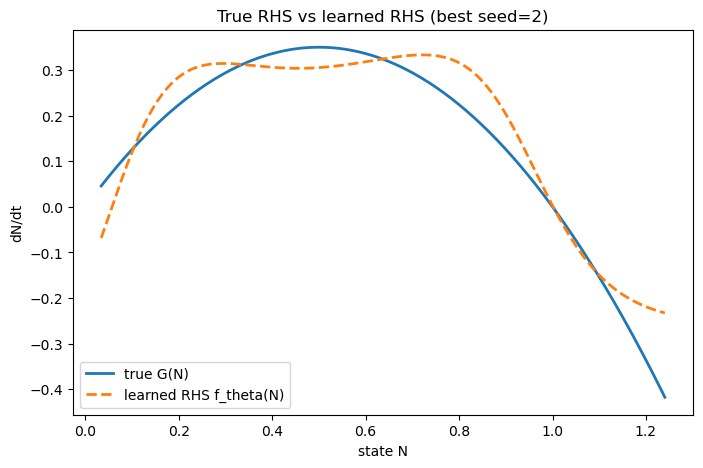

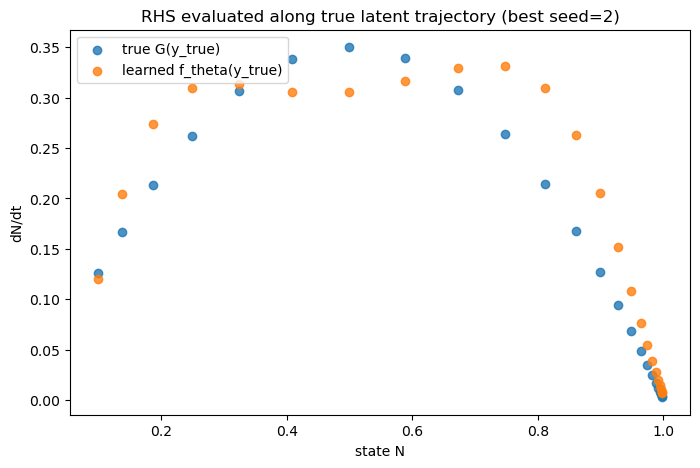

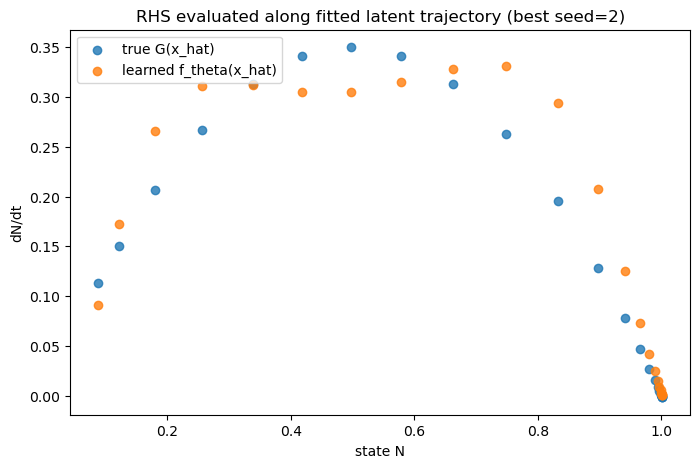

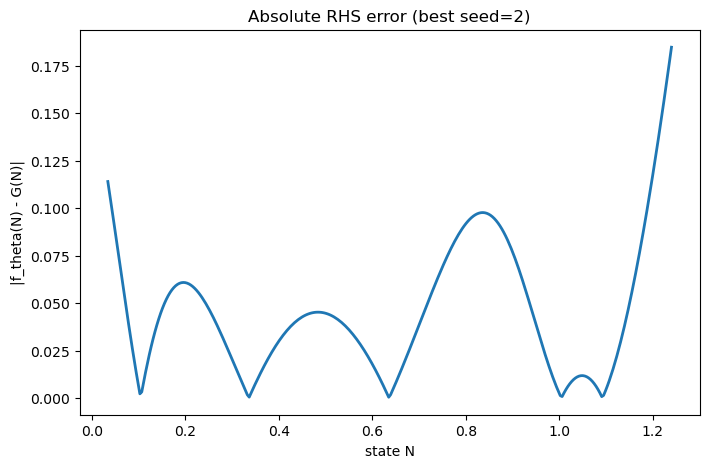

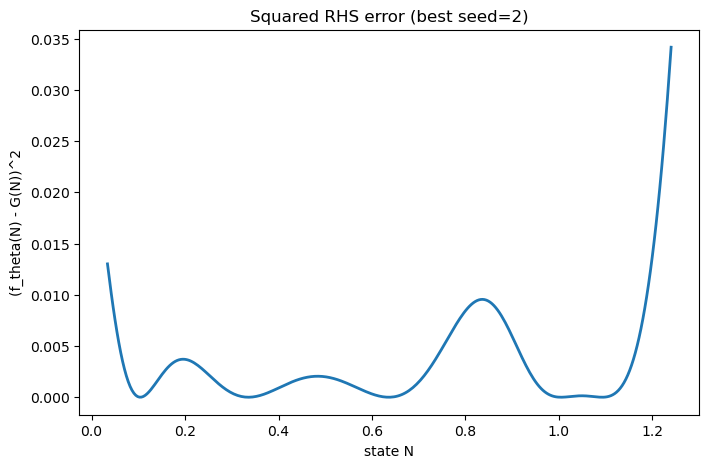

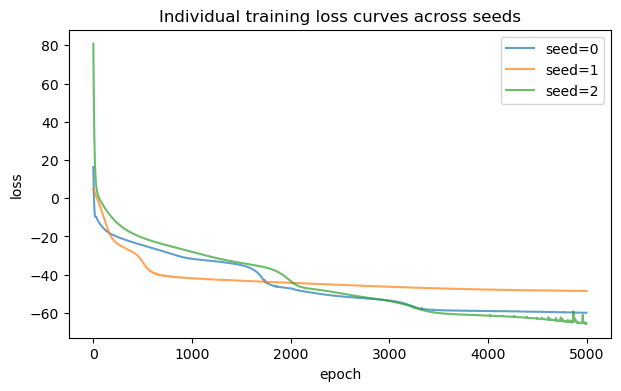

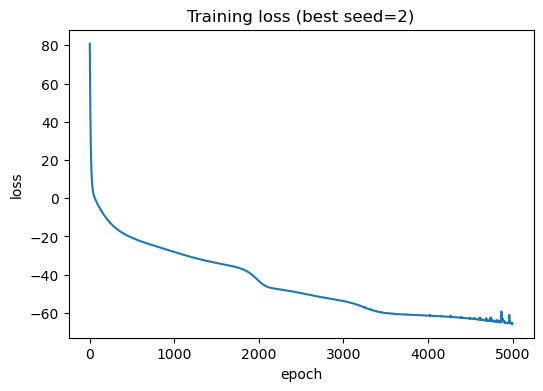

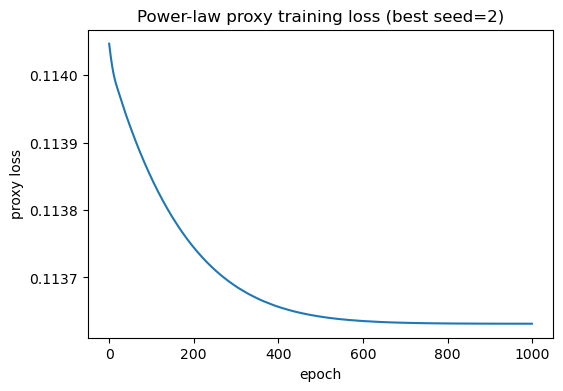

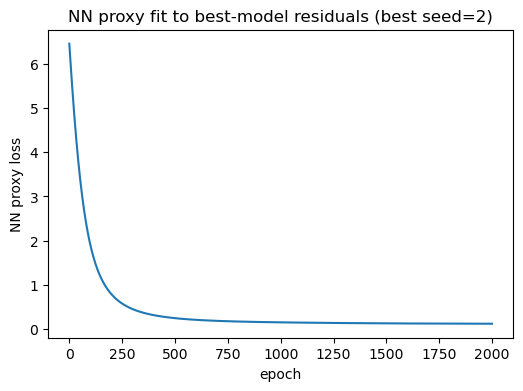

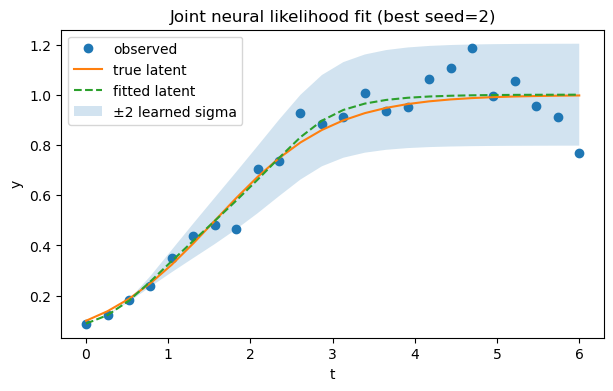

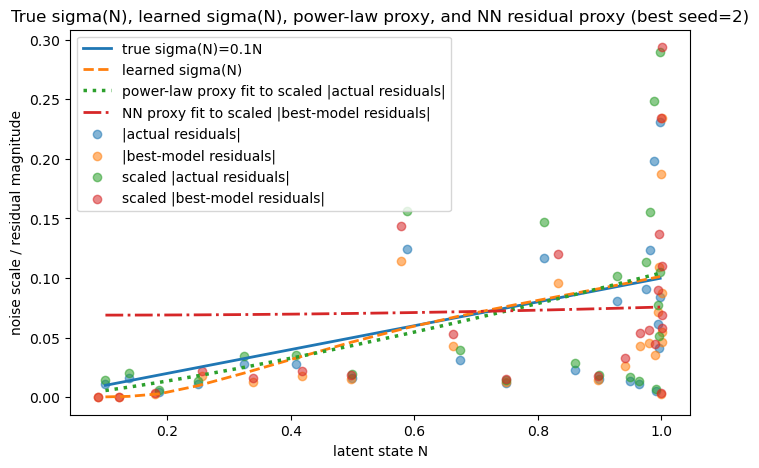

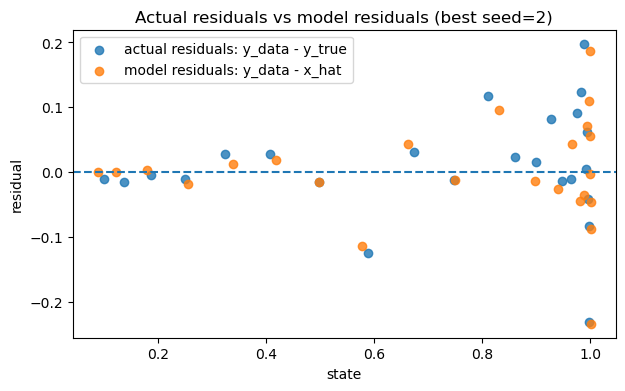

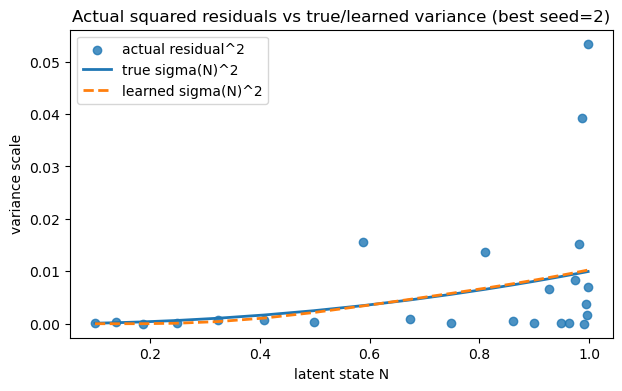

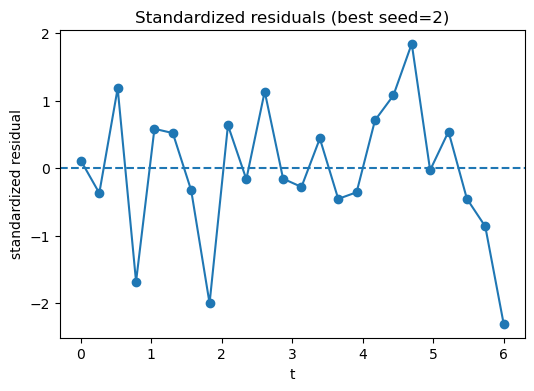


Running initialization 0

[seed=0] epoch=    0 loss=16.273134 nll=16.264786 mono=0.008348 x0=0.7380


KeyboardInterrupt: 

In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 3. Neural RHS model: x' = f_theta(x)
# ============================================================
class DriftNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, t, x):
        return self.net(x)


# ============================================================
# 4. Noise model: log sigma(x) = s_phi(x)
# ============================================================
class NoiseNet(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        log_sigma = self.net(x)
        sigma = torch.exp(log_sigma)
        return sigma, log_sigma


# ============================================================
# 5. Power-law proxy: sigma_proxy(N) = a * N^b
# ============================================================
class PowerLawProxy(nn.Module):
    def __init__(self, a_init=0.1, b_init=1.0):
        super().__init__()

        a_init_u = np.log(np.exp(a_init) - 1.0) if a_init > 1e-8 else -10.0
        b_init_u = np.log(np.exp(b_init) - 1.0) if b_init > 1e-8 else -10.0

        self.a_unconstrained = nn.Parameter(torch.tensor([a_init_u], dtype=torch.float32))
        self.b_unconstrained = nn.Parameter(torch.tensor([b_init_u], dtype=torch.float32))

    def a(self):
        return torch.nn.functional.softplus(self.a_unconstrained) + 1e-8

    def b(self):
        return torch.nn.functional.softplus(self.b_unconstrained) + 1e-8

    def forward(self, x):
        x_safe = torch.where(x > 0.0, x, torch.full_like(x, 1e-8))
        return self.a() * (x_safe ** self.b())


# ============================================================
# 6. NN proxy for residual magnitude
# ============================================================
class ResidualProxyNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return torch.nn.functional.softplus(self.net(x))


# ============================================================
# 7. Full joint model
# ============================================================
class JointNeuralLikelihoodModel(nn.Module):
    def __init__(self, hidden_drift=32, hidden_noise=16, x0_init=0.05):
        super().__init__()
        self.drift = DriftNet(hidden=hidden_drift)
        self.noise = NoiseNet(hidden=hidden_noise)
        self.x0_unconstrained = nn.Parameter(torch.tensor([[x0_init]], dtype=torch.float32))

    def x0(self):
        return torch.nn.functional.softplus(self.x0_unconstrained)

    def latent_traj(self, t):
        x0 = self.x0()
        x_path = odeint_rk4(self.drift, x0, t.squeeze()).squeeze(1)
        return x_path

    def nll(self, t, y_obs):
        x_path = self.latent_traj(t)
        sigma, log_sigma = self.noise(x_path)

        resid = y_obs - x_path
        nll_pointwise = 0.5 * (resid / sigma) ** 2 + log_sigma
        nll = nll_pointwise.sum()

        return nll, {
            "x_path": x_path,
            "sigma": sigma,
            "log_sigma": log_sigma,
            "resid": resid,
            "nll_pointwise": nll_pointwise,
        }


# ============================================================
# 8. Regularization helpers
# ============================================================
def smoothness_penalty_on_path(x_path):
    if len(x_path) < 3:
        return torch.tensor(0.0, device=x_path.device)
    second_diff = x_path[2:] - 2.0 * x_path[1:-1] + x_path[:-2]
    return (second_diff ** 2).sum()

def weight_decay(model):
    reg = 0.0
    for p in model.parameters():
        reg = reg + (p ** 2).sum()
    return reg

def monotonicity_penalty_sigma(x_ref, sigma_ref):
    x_flat = x_ref.squeeze(-1)
    sigma_flat = sigma_ref.squeeze(-1)

    idx = torch.argsort(x_flat)
    sigma_sorted = sigma_flat[idx]
    dsigma = sigma_sorted[1:] - sigma_sorted[:-1]
    return torch.relu(-dsigma).sum()

def sigma_anchor_penalty(sigma):
    return ((sigma - sigma.mean()) ** 2).sum()


# ============================================================
# 9. Train + evaluate one run
# ============================================================
def train_and_evaluate(
    seed,
    max_epochs_model=5000,
    max_epochs_proxy=1000,
    spike_factor=10.0,
    patience_after_best=200,
    grad_norm_spike_threshold=1e4,
    x_path_abs_threshold=10.0,
    sigma_abs_threshold=10.0,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    y_obs = y_data.detach().clone()

    model = JointNeuralLikelihoodModel(
        hidden_drift=8,
        hidden_noise=4,
        x0_init=y_obs[0]
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    loss_history = []
    best_state = None
    best_loss = float("inf")
    terminated_early = False
    termination_reason = "completed"
    best_epoch = -1

    for epoch in range(max_epochs_model):
        optimizer.zero_grad()

        nll, aux = model.nll(t_obs, y_obs)
        x_path = aux["x_path"]
        sigma = aux["sigma"]

        # reg_path = 1e-2 * smoothness_penalty_on_path(x_path)
        # reg_w = 1e-6 * weight_decay(model)
        # reg_sigma = 1e-4 * sigma_anchor_penalty(sigma)
        reg_mono = 1.0 * monotonicity_penalty_sigma(x_path.detach(), sigma)

        loss = nll + reg_mono

        if not torch.isfinite(loss):
            terminated_early = True
            termination_reason = f"non-finite loss at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(x_path).all():
            terminated_early = True
            termination_reason = f"non-finite latent trajectory at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(sigma).all():
            terminated_early = True
            termination_reason = f"non-finite sigma at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        max_abs_x = x_path.abs().max().item()
        max_sigma = sigma.max().item()

        if max_abs_x > x_path_abs_threshold:
            terminated_early = True
            termination_reason = (
                f"latent trajectory exceeded threshold at epoch {epoch} "
                f"(max |x| = {max_abs_x:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if max_sigma > sigma_abs_threshold:
            terminated_early = True
            termination_reason = (
                f"sigma exceeded threshold at epoch {epoch} "
                f"(max sigma = {max_sigma:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        loss.backward()

        total_grad_sq = 0.0
        grad_is_finite = True
        for p in model.parameters():
            if p.grad is not None:
                if not torch.isfinite(p.grad).all():
                    grad_is_finite = False
                    break
                total_grad_sq += (p.grad ** 2).sum().item()

        grad_norm = np.sqrt(total_grad_sq) if grad_is_finite else np.inf

        if not np.isfinite(grad_norm):
            terminated_early = True
            termination_reason = f"non-finite gradient norm at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if grad_norm > grad_norm_spike_threshold:
            terminated_early = True
            termination_reason = (
                f"gradient spike at epoch {epoch} "
                f"(grad_norm = {grad_norm:.6e})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        current_loss = loss.item()
        loss_history.append(current_loss)

        if current_loss < best_loss:
            best_loss = current_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        elif best_loss < float("inf") and current_loss > best_loss + spike_factor:
            print("best loss", best_loss)
            print("spike threshold", best_loss + spike_factor)

            terminated_early = True
            termination_reason = (
                f"loss spike at epoch {epoch} "
                f"(loss = {current_loss:.6e}, best_loss = {best_loss:.6e})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if best_epoch >= 0 and (epoch - best_epoch) > patience_after_best:
            if current_loss > best_loss + 5.0 * max(abs(best_loss), 1.0):
                terminated_early = True
                termination_reason = (
                    f"sustained deterioration after best epoch "
                    f"(epoch = {epoch}, best_epoch = {best_epoch}, "
                    f"loss = {current_loss:.6e}, best_loss = {best_loss:.6e})"
                )
                print(f"[seed={seed}] Terminating: {termination_reason}")
                break

        optimizer.step()

        if epoch % 500 == 0:
            print(
                f"[seed={seed}] "
                f"epoch={epoch:5d} "
                f"loss={loss.item():.6f} "
                f"nll={nll.item():.6f} "
                f"mono={reg_mono.item():.6f} "
                f"x0={model.x0().item():.4f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    # ============================================================
    # 10. Fit power-law proxy to true residuals
    # ============================================================
    with torch.no_grad():
        actual_resid = y_data - y_true
        actual_abs_resid = actual_resid.abs()
        scaled_abs_resid = actual_abs_resid * np.sqrt(np.pi / 2.0)

    proxy_model = PowerLawProxy(a_init=0.1, b_init=1.0).to(device)
    proxy_optim = torch.optim.Adam(proxy_model.parameters(), lr=1e-3)

    proxy_loss_history = []
    best_proxy_state = None
    best_proxy_loss = float("inf")

    for epoch in range(max_epochs_proxy):
        proxy_optim.zero_grad()

        pred_scaled_abs_resid = proxy_model(y_true)

        proxy_data_loss = ((pred_scaled_abs_resid - scaled_abs_resid) ** 2).sum()
        proxy_reg = 1e-6 * (
            (proxy_model.a_unconstrained ** 2).sum() +
            (proxy_model.b_unconstrained ** 2).sum()
        )
        proxy_mono = 1.0 * monotonicity_penalty_sigma(y_true, pred_scaled_abs_resid)

        loss = proxy_data_loss + proxy_reg + proxy_mono
        loss.backward()
        proxy_optim.step()

        proxy_loss_history.append(loss.item())

        if loss.item() < best_proxy_loss:
            best_proxy_loss = loss.item()
            best_proxy_state = copy.deepcopy(proxy_model.state_dict())

    if best_proxy_state is not None:
        proxy_model.load_state_dict(best_proxy_state)

    # ============================================================
    # 11. Evaluate fitted objects
    # ============================================================
    with torch.no_grad():
        nll, aux = model.nll(t_obs, y_obs)

        x_hat = aux["x_path"]
        sigma_hat = aux["sigma"]
        resid = aux["resid"]
        z_hat = resid / sigma_hat

        sigma_true_vals = 0.1 * y_true
        sigma_hat_on_true, _ = model.noise(y_true)
        proxy_sigma_on_true = proxy_model(y_true)

        idx_true = torch.argsort(y_true.squeeze())
        N_true_sorted = y_true[idx_true].squeeze()
        sigma_true_sorted = sigma_true_vals[idx_true].squeeze()
        sigma_hat_true_sorted = sigma_hat_on_true[idx_true].squeeze()
        proxy_sigma_sorted = proxy_sigma_on_true[idx_true].squeeze()
        actual_abs_resid_sorted = actual_abs_resid[idx_true].squeeze()
        scaled_abs_resid_sorted = scaled_abs_resid[idx_true].squeeze()

    return {
        "seed": seed,
        "model": model,
        "proxy_model": proxy_model,
        "loss_history": loss_history,
        "proxy_loss_history": proxy_loss_history,
        "x_hat": x_hat.detach().clone(),
        "sigma_hat": sigma_hat.detach().clone(),
        "resid": resid.detach().clone(),
        "z_hat": z_hat.detach().clone(),
        "sigma_true_vals": sigma_true_vals.detach().clone(),
        "sigma_hat_on_true": sigma_hat_on_true.detach().clone(),
        "proxy_sigma_on_true": proxy_sigma_on_true.detach().clone(),
        "actual_resid": actual_resid.detach().clone(),
        "actual_abs_resid": actual_abs_resid.detach().clone(),
        "scaled_abs_resid": scaled_abs_resid.detach().clone(),
        "N_true_sorted": N_true_sorted.detach().clone(),
        "sigma_true_sorted": sigma_true_sorted.detach().clone(),
        "sigma_hat_true_sorted": sigma_hat_true_sorted.detach().clone(),
        "proxy_sigma_sorted": proxy_sigma_sorted.detach().clone(),
        "actual_abs_resid_sorted": actual_abs_resid_sorted.detach().clone(),
        "scaled_abs_resid_sorted": scaled_abs_resid_sorted.detach().clone(),
        "proxy_a": proxy_model.a().item(),
        "proxy_b": proxy_model.b().item(),
        "terminated_early": terminated_early,
        "termination_reason": termination_reason,
        "best_loss": best_loss,
        "best_epoch": best_epoch,
    }


# ============================================================
# 12. Run over multiple initializations
# ============================================================
num_runs = 3
results = []

for seed in range(num_runs):
    print("\n===============================")
    print(f"Running initialization {seed}")
    print("===============================\n")

    res = train_and_evaluate(seed)
    results.append(res)

    print(
        f"[seed={seed}] fitted power-law proxy: "
        f"sigma_proxy(N) = {res['proxy_a']:.6f} * N^{res['proxy_b']:.6f}"
    )
    print(
        f"[seed={seed}] status: "
        f"terminated_early={res['terminated_early']} "
        f"reason={res['termination_reason']}"
    )

valid_results = [r for r in results if len(r["loss_history"]) > 0]

if len(valid_results) == 0:
    raise RuntimeError("No valid runs completed any optimization steps.")

best_run_idx = int(np.argmin([r["best_loss"] for r in valid_results]))
best_res = valid_results[best_run_idx]

print("\n==========================================")
print(
    f"Best run is seed={best_res['seed']} "
    f"with best_loss={best_res['best_loss']:.6f} "
    f"at best_epoch={best_res['best_epoch']}"
)
print("==========================================\n")


# ============================================================
# 13. Fit NN proxy to residuals from best-fit model wrt data
#     Use scaled |model residual| so target is comparable to sigma
# ============================================================
with torch.no_grad():
    best_model_resid = best_res["resid"]
    best_model_abs_resid = best_model_resid.abs()
    best_model_scaled_abs_resid = best_model_abs_resid * np.sqrt(np.pi / 2.0)

    # Fit as a function of best-fit latent trajectory x_hat
    x_proxy_input = best_res["x_hat"].detach().clone()

resid_nn_proxy = ResidualProxyNet(hidden=4).to(device)
resid_nn_proxy_optim = torch.optim.Adam(resid_nn_proxy.parameters(), lr=1e-3)

best_resid_nn_state = None
best_resid_nn_loss = float("inf")
resid_nn_proxy_loss_history = []

for epoch in range(2000):
    resid_nn_proxy_optim.zero_grad()

    pred_scaled_abs_resid_nn = resid_nn_proxy(x_proxy_input)

    resid_nn_data_loss = ((pred_scaled_abs_resid_nn - best_model_scaled_abs_resid) ** 2).sum()
    resid_nn_reg = 1e-6 * sum((p ** 2).sum() for p in resid_nn_proxy.parameters())
    resid_nn_mono = 1.0 * monotonicity_penalty_sigma(x_proxy_input, pred_scaled_abs_resid_nn)

    loss = resid_nn_data_loss + resid_nn_reg + resid_nn_mono
    loss.backward()
    resid_nn_proxy_optim.step()

    resid_nn_proxy_loss_history.append(loss.item())

    if loss.item() < best_resid_nn_loss:
        best_resid_nn_loss = loss.item()
        best_resid_nn_state = copy.deepcopy(resid_nn_proxy.state_dict())

if best_resid_nn_state is not None:
    resid_nn_proxy.load_state_dict(best_resid_nn_state)


# ============================================================
# 14. Retain only best-seed info
# ============================================================
best_model = best_res["model"]

loss_history = best_res["loss_history"]
proxy_loss_history = best_res["proxy_loss_history"]
x_hat = best_res["x_hat"]
sigma_hat = best_res["sigma_hat"]
resid = best_res["resid"]
z_hat = best_res["z_hat"]
sigma_true_vals = best_res["sigma_true_vals"]
actual_resid = best_res["actual_resid"]
actual_abs_resid = best_res["actual_abs_resid"]
scaled_abs_resid = best_res["scaled_abs_resid"]
N_true_sorted = best_res["N_true_sorted"]
sigma_true_sorted = best_res["sigma_true_sorted"]
sigma_hat_true_sorted = best_res["sigma_hat_true_sorted"]
proxy_sigma_sorted = best_res["proxy_sigma_sorted"]

idx_true = torch.argsort(y_true.squeeze())

with torch.no_grad():
    # evaluate NN proxy on y_true so it can be overlaid on the sigma(N) plot
    resid_nn_sigma_on_true = resid_nn_proxy(y_true)
    resid_nn_sigma_sorted = resid_nn_sigma_on_true[idx_true].squeeze()


# ============================================================
# 15. Plot learned RHS against the true G(N) for the best model
# ============================================================
with torch.no_grad():
    # Choose a grid that covers the relevant state range
    n_min = min(y_true.min().item(), x_hat.min().item(), y_data.min().item())
    n_max = max(y_true.max().item(), x_hat.max().item(), y_data.max().item())

    pad = 0.05 * (n_max - n_min + 1e-6)
    N_grid = torch.linspace(n_min - pad, n_max + pad, 300, device=device).view(-1, 1)

    G_true_grid = G_true(N_grid)
    G_learned_grid = best_model.drift(torch.tensor(0.0, device=device), N_grid)

    # Also evaluate at the true latent states and fitted latent states
    G_true_on_y_true = G_true(y_true)
    G_learned_on_y_true = best_model.drift(torch.tensor(0.0, device=device), y_true)

    G_true_on_x_hat = G_true(x_hat)
    G_learned_on_x_hat = best_model.drift(torch.tensor(0.0, device=device), x_hat)

    rhs_abs_err = (G_learned_grid - G_true_grid).abs()
    rhs_sq_err = (G_learned_grid - G_true_grid) ** 2

# Smooth curve comparison
plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    G_true_grid.cpu().numpy(),
    linewidth=2,
    label="true G(N)"
)
plt.plot(
    N_grid.cpu().numpy(),
    G_learned_grid.cpu().numpy(),
    "--",
    linewidth=2,
    label="learned RHS f_theta(N)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title(f"True RHS vs learned RHS (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Comparison at observed trajectory states
plt.figure(figsize=(8, 5))
plt.scatter(
    y_true.squeeze().cpu().numpy(),
    G_true_on_y_true.squeeze().cpu().numpy(),
    alpha=0.8,
    label="true G(y_true)"
)
plt.scatter(
    y_true.squeeze().cpu().numpy(),
    G_learned_on_y_true.squeeze().cpu().numpy(),
    alpha=0.8,
    label="learned f_theta(y_true)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title(f"RHS evaluated along true latent trajectory (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Comparison at fitted latent states
plt.figure(figsize=(8, 5))
plt.scatter(
    x_hat.squeeze().cpu().numpy(),
    G_true_on_x_hat.squeeze().cpu().numpy(),
    alpha=0.8,
    label="true G(x_hat)"
)
plt.scatter(
    x_hat.squeeze().cpu().numpy(),
    G_learned_on_x_hat.squeeze().cpu().numpy(),
    alpha=0.8,
    label="learned f_theta(x_hat)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title(f"RHS evaluated along fitted latent trajectory (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Pointwise error on the grid
plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    rhs_abs_err.cpu().numpy(),
    linewidth=2
)
plt.xlabel("state N")
plt.ylabel("|f_theta(N) - G(N)|")
plt.title(f"Absolute RHS error (best seed={best_res['seed']})")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    rhs_sq_err.cpu().numpy(),
    linewidth=2
)
plt.xlabel("state N")
plt.ylabel("(f_theta(N) - G(N))^2")
plt.title(f"Squared RHS error (best seed={best_res['seed']})")
plt.show()


# ============================================================
# 16. Plot diagnostics
# ============================================================

# Individual training loss curves across seeds
plt.figure(figsize=(7, 4))
for r in valid_results:
    plt.plot(r["loss_history"], alpha=0.7, linewidth=1.5, label=f"seed={r['seed']}")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Individual training loss curves across seeds")
plt.legend()
plt.show()

# Training loss: best run only
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title(f"Training loss (best seed={best_res['seed']})")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

# Power-law proxy training loss
plt.figure(figsize=(6, 4))
plt.plot(proxy_loss_history)
plt.xlabel("epoch")
plt.ylabel("proxy loss")
plt.title(f"Power-law proxy training loss (best seed={best_res['seed']})")
plt.show()

# NN proxy training loss for best-fit model residuals
plt.figure(figsize=(6, 4))
plt.plot(resid_nn_proxy_loss_history)
plt.xlabel("epoch")
plt.ylabel("NN proxy loss")
plt.title(f"NN proxy fit to best-model residuals (best seed={best_res['seed']})")
plt.show()

# Representative trajectory fit: best run only
plt.figure(figsize=(7, 4))
plt.plot(t_obs.cpu(), y_data.cpu(), "o", label="observed")
plt.plot(t_obs.cpu(), y_true.cpu(), "-", label="true latent")
plt.plot(t_obs.cpu(), x_hat.cpu(), "--", label="fitted latent")
plt.fill_between(
    t_obs.squeeze().cpu().numpy(),
    (x_hat - 2 * sigma_hat).squeeze().cpu().numpy(),
    (x_hat + 2 * sigma_hat).squeeze().cpu().numpy(),
    alpha=0.2,
    label="±2 learned sigma"
)
plt.legend()
plt.xlabel("t")
plt.ylabel("y")
plt.title(f"Joint neural likelihood fit (best seed={best_res['seed']})")
plt.show()

# Main sigma comparison plot: best run only
plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_hat_true_sorted.cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)"
)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_hat_true_sorted.cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)"
)
plt.plot(
    N_true_sorted.cpu(),
    proxy_sigma_sorted.cpu(),
    ":",
    linewidth=2.5,
    label="power-law proxy fit to scaled |actual residuals|"
)
plt.plot(
    N_true_sorted.cpu(),
    resid_nn_sigma_sorted.cpu(),
    "-.",
    linewidth=2.0,
    label="NN proxy fit to scaled |best-model residuals|"
)
plt.scatter(
    y_true.squeeze().cpu(),
    actual_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="|actual residuals|"
)
plt.scatter(
    x_hat.squeeze().cpu(),
    best_model_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="|best-model residuals|"
)
plt.scatter(
    y_true.squeeze().cpu(),
    scaled_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="scaled |actual residuals|"
)
plt.scatter(
    x_hat.squeeze().cpu(),
    best_model_scaled_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="scaled |best-model residuals|"
)
plt.xlabel("latent state N")
plt.ylabel("noise scale / residual magnitude")
plt.title(
    f"True sigma(N), learned sigma(N), power-law proxy, and NN residual proxy "
    f"(best seed={best_res['seed']})"
)
plt.legend()
plt.show()

# Residuals: actual vs model residuals
plt.figure(figsize=(7, 4))
plt.axhline(0.0, linestyle="--")
plt.scatter(
    y_true.squeeze().cpu(),
    actual_resid.squeeze().cpu(),
    label="actual residuals: y_data - y_true",
    alpha=0.8
)
plt.scatter(
    x_hat.squeeze().cpu(),
    resid.squeeze().cpu(),
    label="model residuals: y_data - x_hat",
    alpha=0.8
)
plt.xlabel("state")
plt.ylabel("residual")
plt.title(f"Actual residuals vs model residuals (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Squared residuals vs variance curves
plt.figure(figsize=(7, 4))
plt.scatter(
    y_true.squeeze().cpu(),
    (actual_resid ** 2).squeeze().cpu(),
    alpha=0.8,
    label="actual residual^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_true_sorted ** 2).cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_hat_true_sorted ** 2).cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)^2"
)
plt.xlabel("latent state N")
plt.ylabel("variance scale")
plt.title(f"Actual squared residuals vs true/learned variance (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Standardized residuals
plt.figure(figsize=(6, 4))
plt.plot(t_obs.cpu(), z_hat.cpu(), "o-")
plt.axhline(0.0, linestyle="--")
plt.xlabel("t")
plt.ylabel("standardized residual")
plt.title(f"Standardized residuals (best seed={best_res['seed']})")
plt.show()

## Multiple IC


Running initialization 0

[seed=0] epoch=    0 loss=0.699640 train_nll=0.690470 val_nll=0.878178 mono=0.009170 x0=[0.71506774 0.73096186 0.73063207 0.7353554  0.8158141 ]
[seed=0] epoch=  500 loss=-1.007861 train_nll=-1.012104 val_nll=-1.122769 mono=0.004244 x0=[0.4855921  0.50623965 0.5294692  0.51914215 0.5686563 ]
[seed=0] epoch= 1000 loss=-1.266090 train_nll=-1.271388 val_nll=-1.379153 mono=0.005298 x0=[0.3204527  0.34745365 0.37520885 0.36575678 0.43724152]
[seed=0] epoch= 1500 loss=-1.519058 train_nll=-1.521257 val_nll=-1.611051 mono=0.002199 x0=[0.2113889  0.24284548 0.27056548 0.26577938 0.35786888]
[seed=0] epoch= 2000 loss=-2.018753 train_nll=-2.018753 val_nll=-2.052207 mono=0.000000 x0=[0.16213232 0.17012155 0.17565183 0.18127552 0.21556742]
[seed=0] epoch= 2500 loss=-2.110514 train_nll=-2.110514 val_nll=-2.143405 mono=0.000000 x0=[0.12504575 0.13688709 0.14380533 0.1520078  0.19487461]
[seed=0] epoch= 3000 loss=-2.165507 train_nll=-2.165507 val_nll=-2.192689 mono=0.000000 

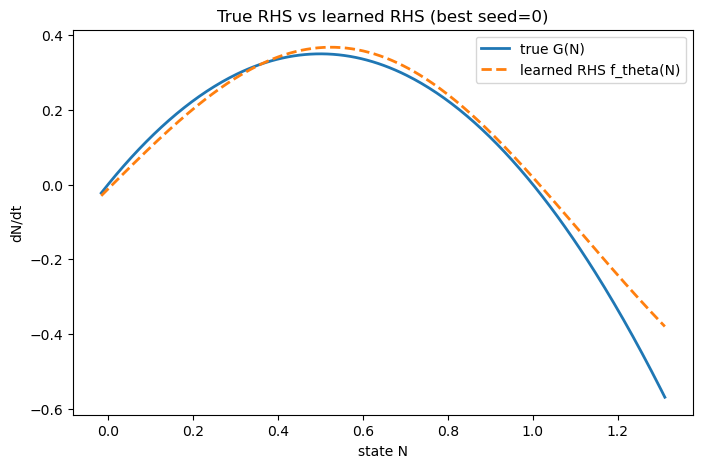

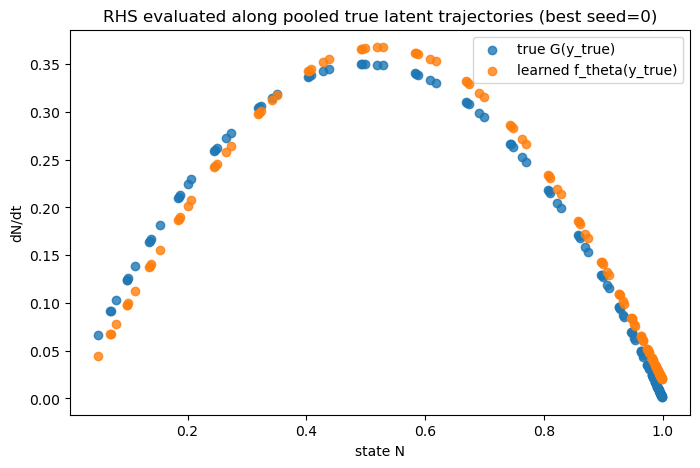

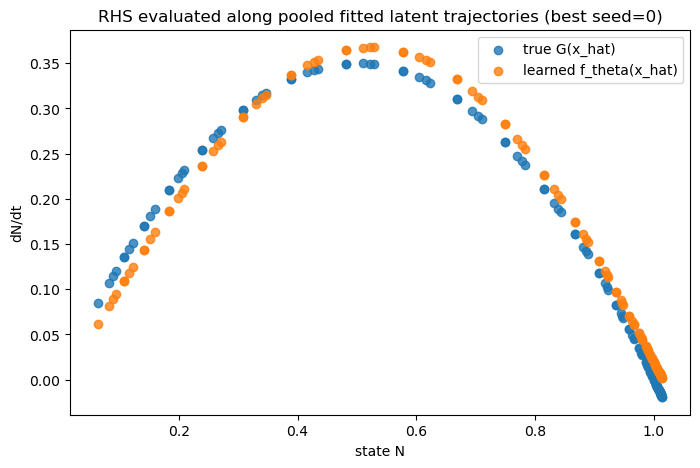

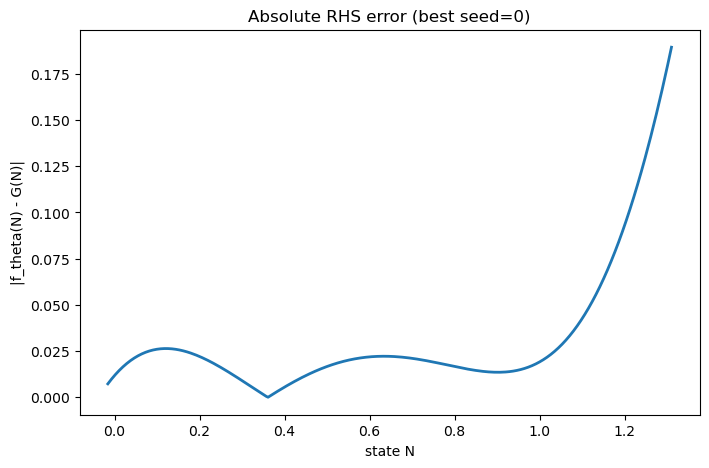

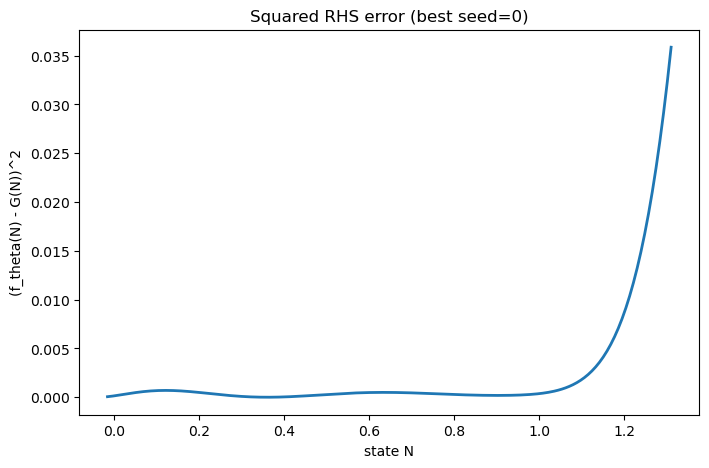

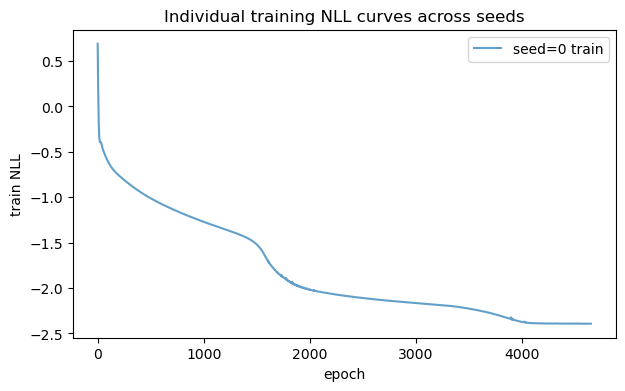

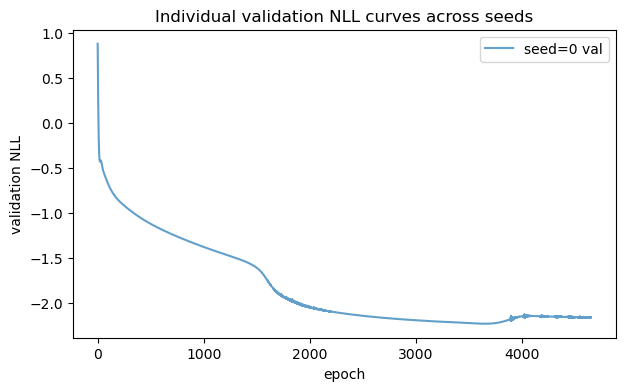

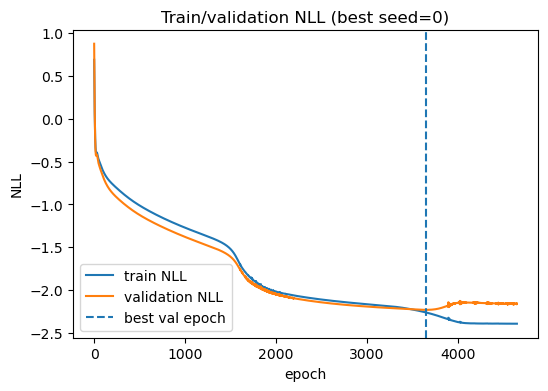

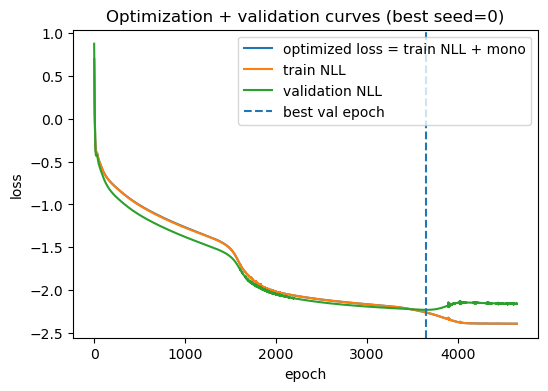

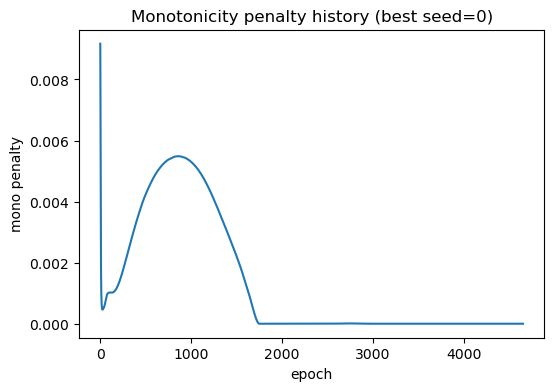

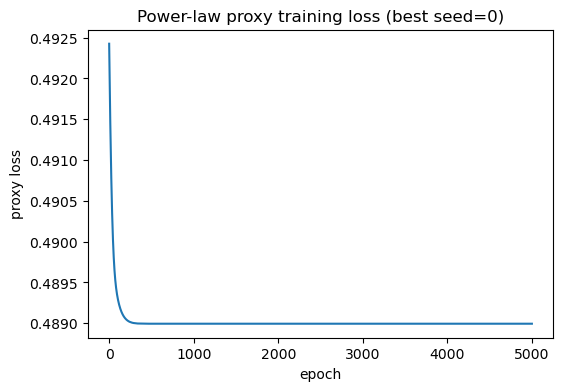

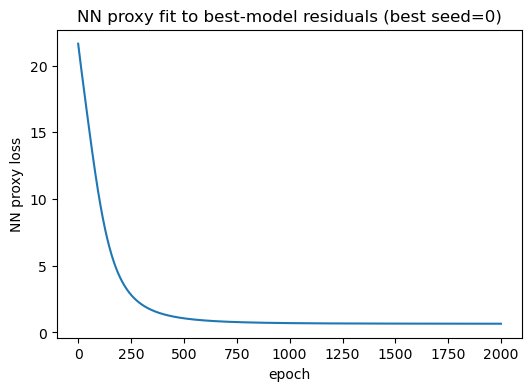

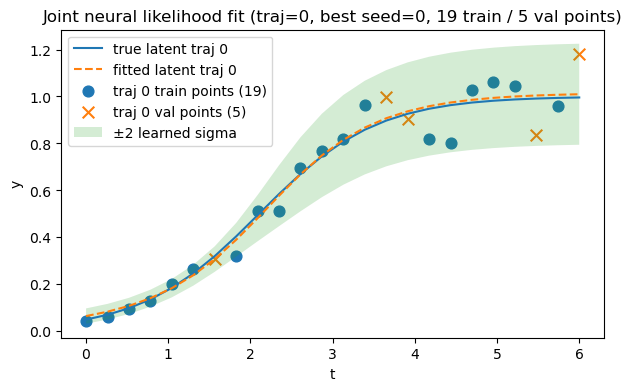

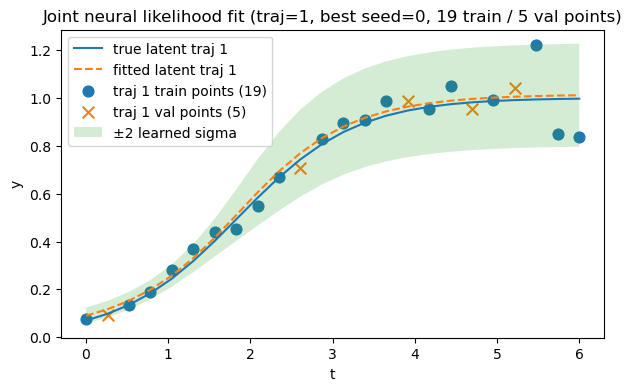

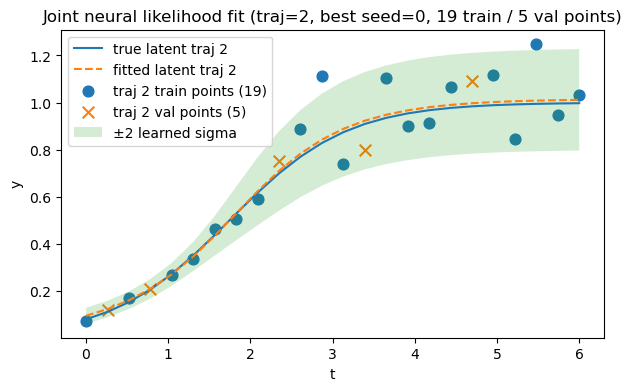

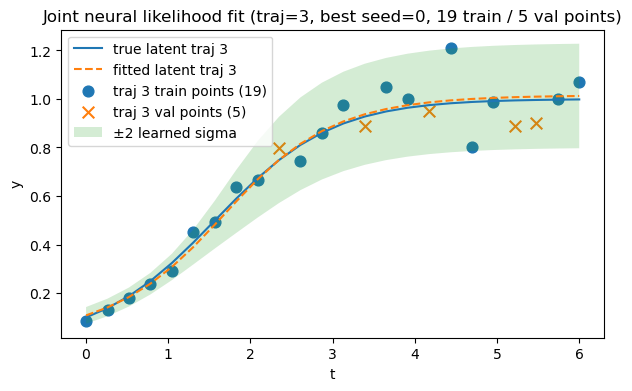

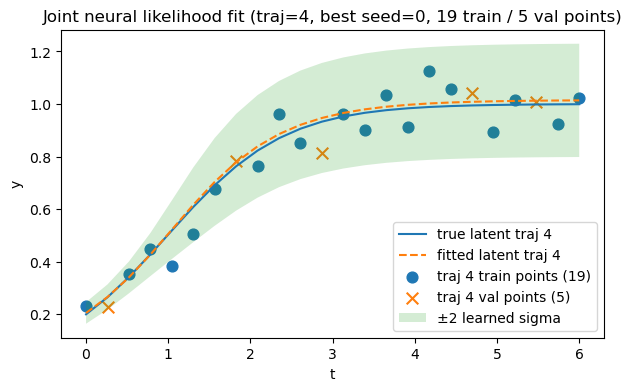

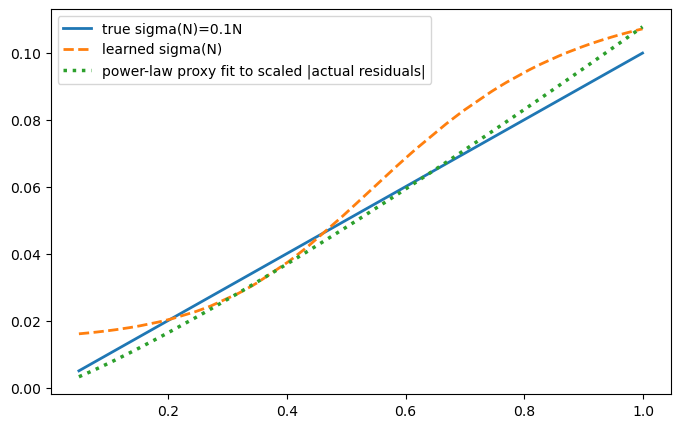

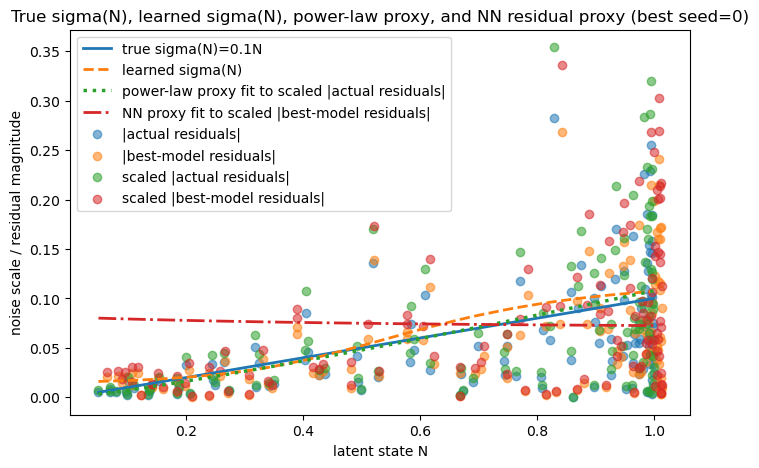

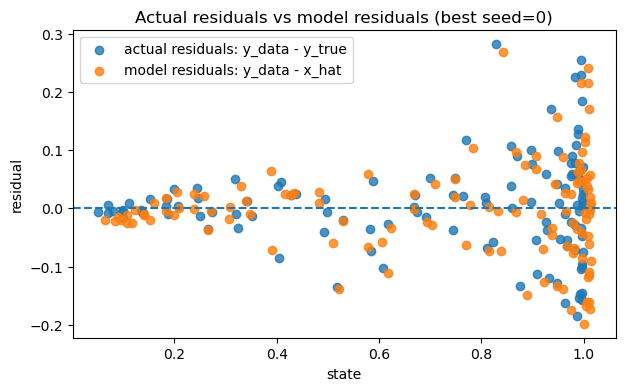

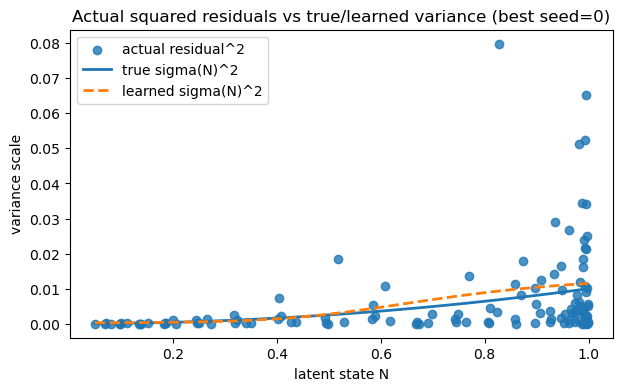

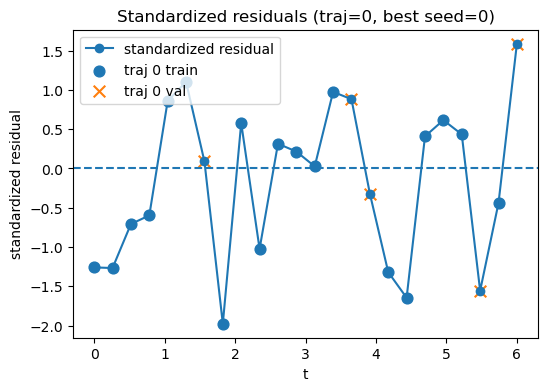

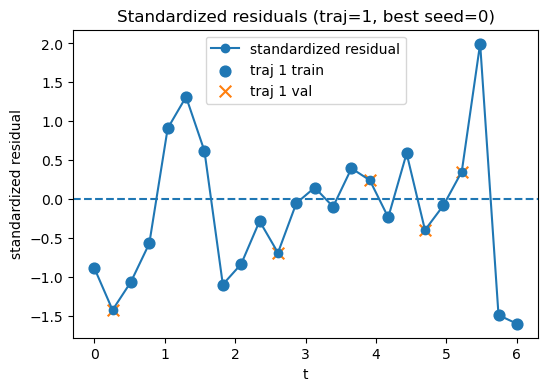

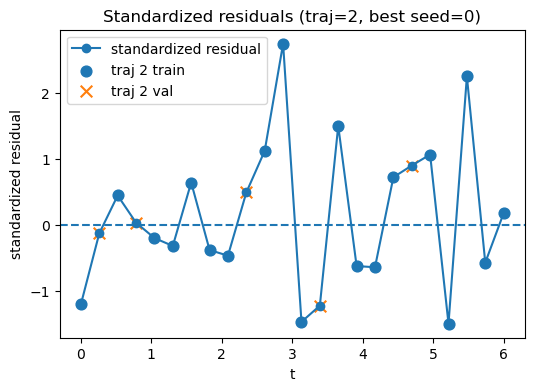

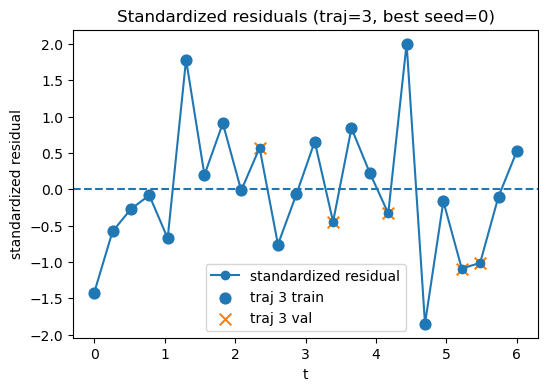

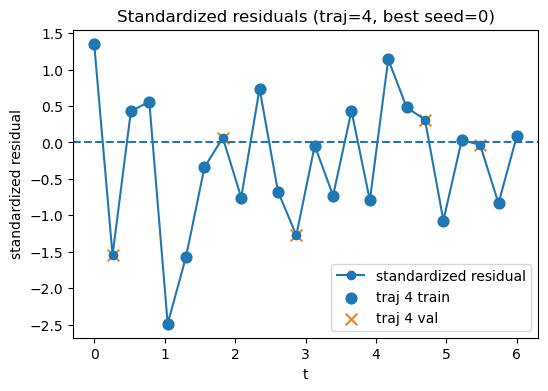

In [12]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0_all = torch.tensor([[0.05], [0.07], [0.08], [0.10], [0.20]], dtype=torch.float32, device=device)
num_trajectories = N0_all.shape[0]

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y_true_list = []
    for i in range(num_trajectories):
        y0_true = N0_all[i:i+1]  # [1,1]
        y_true_i = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)  # [T,1]
        y_true_list.append(y_true_i)
    y_true = torch.stack(y_true_list, dim=0)  # [M,T,1]

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 3. Neural RHS model: x' = f_theta(x)
# ============================================================
class DriftNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, t, x):
        return self.net(x)


# ============================================================
# 4. Noise model: log sigma(x) = s_phi(x)
# ============================================================
class NoiseNet(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        log_sigma = self.net(x)
        sigma = torch.exp(log_sigma)
        return sigma, log_sigma


# ============================================================
# 5. Power-law proxy: sigma_proxy(N) = a * N^b
# ============================================================
class PowerLawProxy(nn.Module):
    def __init__(self, a_init=0.1, b_init=1.0):
        super().__init__()

        a_init_u = np.log(np.exp(a_init) - 1.0) if a_init > 1e-8 else -10.0
        b_init_u = np.log(np.exp(b_init) - 1.0) if b_init > 1e-8 else -10.0

        self.a_unconstrained = nn.Parameter(torch.tensor([a_init_u], dtype=torch.float32))
        self.b_unconstrained = nn.Parameter(torch.tensor([b_init_u], dtype=torch.float32))

    def a(self):
        return torch.nn.functional.softplus(self.a_unconstrained) + 1e-8

    def b(self):
        return torch.nn.functional.softplus(self.b_unconstrained) + 1e-8

    def forward(self, x):
        x_safe = torch.where(x > 0.0, x, torch.full_like(x, 1e-8))
        return self.a() * (x_safe ** self.b())


# ============================================================
# 6. NN proxy for residual magnitude
# ============================================================
class ResidualProxyNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return torch.nn.functional.softplus(self.net(x))


# ============================================================
# 7. Full joint model
# ============================================================
class JointNeuralLikelihoodModel(nn.Module):
    def __init__(self, num_trajectories, hidden_drift=32, hidden_noise=16, x0_init=None):
        super().__init__()
        self.drift = DriftNet(hidden=hidden_drift)
        self.noise = NoiseNet(hidden=hidden_noise)

        if x0_init is None:
            x0_init = 0.05 * torch.ones(num_trajectories, 1, dtype=torch.float32)
        self.x0_unconstrained = nn.Parameter(x0_init.clone())

    def x0(self):
        return torch.nn.functional.softplus(self.x0_unconstrained)  # [M,1]

    def latent_traj(self, t):
        x0_all = self.x0()  # [M,1]
        x_paths = []
        for i in range(x0_all.shape[0]):
            x0_i = x0_all[i:i+1]  # [1,1]
            x_path_i = odeint_rk4(self.drift, x0_i, t.squeeze()).squeeze(1)  # [T,1]
            x_paths.append(x_path_i)
        return torch.stack(x_paths, dim=0)  # [M,T,1]

    def nll(self, t, y_obs):
        x_path = self.latent_traj(t)   # [M,T,1]
        sigma, log_sigma = self.noise(x_path)

        resid = y_obs - x_path
        nll_pointwise = 0.5 * (resid / sigma) ** 2 + log_sigma

        # Equal weight per trajectory over all points
        nll_per_traj = nll_pointwise.sum(dim=(1, 2))  # [M]
        nll = nll_per_traj.mean()

        return nll, {
            "x_path": x_path,
            "sigma": sigma,
            "log_sigma": log_sigma,
            "resid": resid,
            "nll_pointwise": nll_pointwise,
            "nll_per_traj": nll_per_traj,
        }


# ============================================================
# 8. Regularization helpers
# ============================================================
def smoothness_penalty_on_path(x_path):
    if x_path.dim() == 2:
        if len(x_path) < 3:
            return torch.tensor(0.0, device=x_path.device)
        second_diff = x_path[2:] - 2.0 * x_path[1:-1] + x_path[:-2]
        return (second_diff ** 2).sum()

    elif x_path.dim() == 3:
        if x_path.shape[1] < 3:
            return torch.tensor(0.0, device=x_path.device)
        second_diff = x_path[:, 2:] - 2.0 * x_path[:, 1:-1] + x_path[:, :-2]
        return (second_diff ** 2).sum()

    else:
        raise ValueError("Unexpected x_path shape")

def weight_decay(model):
    reg = 0.0
    for p in model.parameters():
        reg = reg + (p ** 2).sum()
    return reg

def monotonicity_penalty_sigma(x_ref, sigma_ref):
    x_flat = x_ref.reshape(-1)
    sigma_flat = sigma_ref.reshape(-1)

    idx = torch.argsort(x_flat)
    sigma_sorted = sigma_flat[idx]
    dsigma = sigma_sorted[1:] - sigma_sorted[:-1]
    return torch.relu(-dsigma).sum()

def sigma_anchor_penalty(sigma):
    return ((sigma - sigma.mean()) ** 2).sum()

def masked_mean_nll(nll_pointwise, mask):
    """
    nll_pointwise: [M,T,1]
    mask:         [M,T,1] with 0/1 entries
    returns average NLL per observed point over the masked region
    """
    masked_sum = (nll_pointwise * mask).sum()
    denom = mask.sum().clamp_min(1.0)
    return masked_sum / denom



# ============================================================
# 9. Train/validation split helper
# ============================================================
def make_time_split_masks(
    num_trajectories,
    num_timepoints,
    train_fraction=0.8,
    device="cpu",
    generator=None,
):
    """
    Random split within each trajectory.

    For every trajectory separately:
        - randomly assign roughly train_fraction of its time points to train
        - assign the rest to validation

    This guarantees the same train/val fraction per trajectory.
    """
    num_train_per_traj = max(1, int(np.floor(train_fraction * num_timepoints)))
    num_train_per_traj = min(num_train_per_traj, num_timepoints - 1)  # keep at least one val point
    num_val_per_traj = num_timepoints - num_train_per_traj

    train_mask = torch.zeros(
        num_trajectories, num_timepoints, 1,
        dtype=torch.float32,
        device=device
    )
    val_mask = torch.zeros_like(train_mask)

    for i in range(num_trajectories):
        perm = torch.randperm(num_timepoints, generator=generator, device=device)
        train_idx = perm[:num_train_per_traj]
        val_idx = perm[num_train_per_traj:]

        train_mask[i, train_idx, 0] = 1.0
        val_mask[i, val_idx, 0] = 1.0

    return train_mask, val_mask, num_train_per_traj, num_val_per_traj


# ============================================================
# 10. Train + evaluate one run
# ============================================================
def train_and_evaluate(
    seed,
    max_epochs_model=10000,
    max_epochs_proxy=5000,
    patience_val=1000,
    min_delta_val=1e-5,
    grad_norm_spike_threshold=1e4,
    x_path_abs_threshold=10.0,
    sigma_abs_threshold=10.0,
    train_fraction=0.8,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    y_obs = y_data.detach().clone()  # [M,T,1]

    M, T, _ = y_obs.shape

    split_generator = torch.Generator(device=device)
    split_generator.manual_seed(seed)

    train_mask, val_mask, num_train_per_traj, num_val_per_traj = make_time_split_masks(
        num_trajectories=M,
        num_timepoints=T,
        train_fraction=train_fraction,
        device=device,
        generator=split_generator,
    )

    model = JointNeuralLikelihoodModel(
        num_trajectories=y_obs.shape[0],
        hidden_drift=8,
        hidden_noise=4,
        x0_init=y_obs[:, 0, :]   # [M,1]
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    total_loss_history = []
    train_nll_history = []
    val_nll_history = []
    reg_mono_history = []

    best_state = None
    best_val_loss = float("inf")
    best_train_loss = float("inf")
    best_epoch = -1

    terminated_early = False
    termination_reason = "completed"
    epochs_since_best_val = 0

    for epoch in range(max_epochs_model):
        optimizer.zero_grad()

        _, aux = model.nll(t_obs, y_obs)
        x_path = aux["x_path"]
        sigma = aux["sigma"]
        nll_pointwise = aux["nll_pointwise"]

        train_nll = masked_mean_nll(nll_pointwise, train_mask)
        val_nll = masked_mean_nll(nll_pointwise.detach(), val_mask)

        reg_mono = 1.0 * monotonicity_penalty_sigma(x_path.detach(), sigma)
        loss = train_nll + reg_mono

        if not torch.isfinite(loss):
            terminated_early = True
            termination_reason = f"non-finite loss at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(train_nll):
            terminated_early = True
            termination_reason = f"non-finite train NLL at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(val_nll):
            terminated_early = True
            termination_reason = f"non-finite validation NLL at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(x_path).all():
            terminated_early = True
            termination_reason = f"non-finite latent trajectory at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(sigma).all():
            terminated_early = True
            termination_reason = f"non-finite sigma at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        max_abs_x = x_path.abs().max().item()
        max_sigma = sigma.max().item()

        if max_abs_x > x_path_abs_threshold:
            terminated_early = True
            termination_reason = (
                f"latent trajectory exceeded threshold at epoch {epoch} "
                f"(max |x| = {max_abs_x:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if max_sigma > sigma_abs_threshold:
            terminated_early = True
            termination_reason = (
                f"sigma exceeded threshold at epoch {epoch} "
                f"(max sigma = {max_sigma:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        loss.backward()

        total_grad_sq = 0.0
        grad_is_finite = True
        for p in model.parameters():
            if p.grad is not None:
                if not torch.isfinite(p.grad).all():
                    grad_is_finite = False
                    break
                total_grad_sq += (p.grad ** 2).sum().item()

        grad_norm = np.sqrt(total_grad_sq) if grad_is_finite else np.inf

        if not np.isfinite(grad_norm):
            terminated_early = True
            termination_reason = f"non-finite gradient norm at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if grad_norm > grad_norm_spike_threshold:
            terminated_early = True
            termination_reason = (
                f"gradient spike at epoch {epoch} "
                f"(grad_norm = {grad_norm:.6e})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        optimizer.step()

        current_total = loss.item()
        current_train = train_nll.item()
        current_val = val_nll.item()
        current_reg = reg_mono.item()
        current_val += current_reg

        total_loss_history.append(current_total)
        train_nll_history.append(current_train)
        val_nll_history.append(current_val)
        reg_mono_history.append(current_reg)

        if current_train < best_train_loss:
            best_train_loss = current_train

        if current_val < best_val_loss - min_delta_val:
            best_val_loss = current_val
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_since_best_val = 0
        else:
            epochs_since_best_val += 1

        if epochs_since_best_val > patience_val:
            terminated_early = True
            termination_reason = (
                f"validation patience exhausted at epoch {epoch} "
                f"(best_epoch={best_epoch}, best_val_loss={best_val_loss:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if epoch % 500 == 0:
            print(
                f"[seed={seed}] "
                f"epoch={epoch:5d} "
                f"loss={current_total:.6f} "
                f"train_nll={current_train:.6f} "
                f"val_nll={current_val:.6f} "
                f"mono={current_reg:.6f} "
                f"x0={model.x0().detach().squeeze(-1).cpu().numpy()}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    # ============================================================
    # 11. Fit power-law proxy to true residuals
    # ============================================================
    with torch.no_grad():
        actual_resid = y_data - y_true             # [M,T,1]
        actual_abs_resid = actual_resid.abs()
        scaled_abs_resid = actual_abs_resid * np.sqrt(np.pi / 2.0)

    proxy_model = PowerLawProxy(a_init=0.1, b_init=1.0).to(device)
    proxy_optim = torch.optim.Adam(proxy_model.parameters(), lr=1e-3)

    proxy_loss_history = []
    best_proxy_state = None
    best_proxy_loss = float("inf")

    for epoch in range(max_epochs_proxy):
        proxy_optim.zero_grad()

        pred_scaled_abs_resid = proxy_model(y_true)

        proxy_data_loss = ((pred_scaled_abs_resid - scaled_abs_resid) ** 2).sum()
        proxy_reg = 1e-6 * (
            (proxy_model.a_unconstrained ** 2).sum() +
            (proxy_model.b_unconstrained ** 2).sum()
        )
        proxy_mono = 1.0 * monotonicity_penalty_sigma(y_true, pred_scaled_abs_resid)

        loss = proxy_data_loss + proxy_mono
        loss.backward()
        proxy_optim.step()

        proxy_loss_history.append(loss.item())

        if loss.item() < best_proxy_loss:
            best_proxy_loss = loss.item()
            best_proxy_state = copy.deepcopy(proxy_model.state_dict())

    if best_proxy_state is not None:
        proxy_model.load_state_dict(best_proxy_state)

    # ============================================================
    # 12. Evaluate fitted objects
    # ============================================================
    with torch.no_grad():
        _, aux = model.nll(t_obs, y_obs)

        x_hat = aux["x_path"]
        sigma_hat = aux["sigma"]
        resid = aux["resid"]
        z_hat = resid / sigma_hat

        final_train_nll = masked_mean_nll(aux["nll_pointwise"], train_mask).item()
        final_val_nll = masked_mean_nll(aux["nll_pointwise"], val_mask).item()

        sigma_true_vals = 0.1 * y_true
        sigma_hat_on_true, _ = model.noise(y_true)
        proxy_sigma_on_true = proxy_model(y_true)

        y_true_flat = y_true.reshape(-1, 1)
        sigma_true_flat = sigma_true_vals.reshape(-1, 1)
        sigma_hat_true_flat = sigma_hat_on_true.reshape(-1, 1)
        proxy_sigma_flat = proxy_sigma_on_true.reshape(-1, 1)
        actual_abs_resid_flat = actual_abs_resid.reshape(-1, 1)
        scaled_abs_resid_flat = scaled_abs_resid.reshape(-1, 1)

        idx_true = torch.argsort(y_true_flat.squeeze())
        N_true_sorted = y_true_flat[idx_true].squeeze()
        sigma_true_sorted = sigma_true_flat[idx_true].squeeze()
        sigma_hat_true_sorted = sigma_hat_true_flat[idx_true].squeeze()
        proxy_sigma_sorted = proxy_sigma_flat[idx_true].squeeze()
        actual_abs_resid_sorted = actual_abs_resid_flat[idx_true].squeeze()
        scaled_abs_resid_sorted = scaled_abs_resid_flat[idx_true].squeeze()

    return {
        "seed": seed,
        "model": model,
        "proxy_model": proxy_model,
        "total_loss_history": total_loss_history,
        "train_nll_history": train_nll_history,
        "val_nll_history": val_nll_history,
        "reg_mono_history": reg_mono_history,
        "proxy_loss_history": proxy_loss_history,
        "x_hat": x_hat.detach().clone(),
        "sigma_hat": sigma_hat.detach().clone(),
        "resid": resid.detach().clone(),
        "z_hat": z_hat.detach().clone(),
        "sigma_true_vals": sigma_true_vals.detach().clone(),
        "sigma_hat_on_true": sigma_hat_on_true.detach().clone(),
        "proxy_sigma_on_true": proxy_sigma_on_true.detach().clone(),
        "actual_resid": actual_resid.detach().clone(),
        "actual_abs_resid": actual_abs_resid.detach().clone(),
        "scaled_abs_resid": scaled_abs_resid.detach().clone(),
        "N_true_sorted": N_true_sorted.detach().clone(),
        "sigma_true_sorted": sigma_true_sorted.detach().clone(),
        "sigma_hat_true_sorted": sigma_hat_true_sorted.detach().clone(),
        "proxy_sigma_sorted": proxy_sigma_sorted.detach().clone(),
        "actual_abs_resid_sorted": actual_abs_resid_sorted.detach().clone(),
        "scaled_abs_resid_sorted": scaled_abs_resid_sorted.detach().clone(),
        "proxy_a": proxy_model.a().item(),
        "proxy_b": proxy_model.b().item(),
        "terminated_early": terminated_early,
        "termination_reason": termination_reason,
        "best_val_loss": best_val_loss,
        "best_train_loss": best_train_loss,
        "best_epoch": best_epoch,
        "final_train_nll": final_train_nll,
        "final_val_nll": final_val_nll,
        "train_mask": train_mask.detach().clone(),
        "val_mask": val_mask.detach().clone(),
        "num_train_per_traj": num_train_per_traj,
        "num_val_per_traj": num_val_per_traj,
    }


# ============================================================
# 13. Run over multiple initializations
# ============================================================
num_runs = 1
results = []

for seed in range(num_runs):
    print("\n===============================")
    print(f"Running initialization {seed}")
    print("===============================\n")

    res = train_and_evaluate(seed)
    results.append(res)

    print(
        f"[seed={seed}] fitted power-law proxy: "
        f"sigma_proxy(N) = {res['proxy_a']:.6f} * N^{res['proxy_b']:.6f}"
    )
    print(
        f"[seed={seed}] status: "
        f"terminated_early={res['terminated_early']} "
        f"reason={res['termination_reason']}"
    )
    print(
        f"[seed={seed}] best_val_loss={res['best_val_loss']:.6f} "
        f"best_epoch={res['best_epoch']} "
        f"final_train_nll={res['final_train_nll']:.6f} "
        f"final_val_nll={res['final_val_nll']:.6f}"
    )

valid_results = [r for r in results if len(r["train_nll_history"]) > 0]

if len(valid_results) == 0:
    raise RuntimeError("No valid runs completed any optimization steps.")

best_run_idx = int(np.argmin([r["best_val_loss"] for r in valid_results]))
best_res = valid_results[best_run_idx]

print("\n==========================================")
print(
    f"Best run is seed={best_res['seed']} "
    f"with best_val_loss={best_res['best_val_loss']:.6f} "
    f"at best_epoch={best_res['best_epoch']}"
)
print("==========================================\n")


# ============================================================
# 14. Fit NN proxy to residuals from best-fit model wrt data
#     Use scaled |model residual| so target is comparable to sigma
# ============================================================
with torch.no_grad():
    best_model_resid = best_res["resid"]                            # [M,T,1]
    best_model_abs_resid = best_model_resid.abs()
    best_model_scaled_abs_resid = best_model_abs_resid * np.sqrt(np.pi / 2.0)

    x_proxy_input = best_res["x_hat"].detach().clone()             # [M,T,1]

resid_nn_proxy = ResidualProxyNet(hidden=4).to(device)
resid_nn_proxy_optim = torch.optim.Adam(resid_nn_proxy.parameters(), lr=1e-3)

best_resid_nn_state = None
best_resid_nn_loss = float("inf")
resid_nn_proxy_loss_history = []

for epoch in range(2000):
    resid_nn_proxy_optim.zero_grad()

    pred_scaled_abs_resid_nn = resid_nn_proxy(x_proxy_input)

    resid_nn_data_loss = ((pred_scaled_abs_resid_nn - best_model_scaled_abs_resid) ** 2).sum()
    resid_nn_reg = 1e-6 * sum((p ** 2).sum() for p in resid_nn_proxy.parameters())
    resid_nn_mono = 1.0 * monotonicity_penalty_sigma(x_proxy_input, pred_scaled_abs_resid_nn)

    loss = resid_nn_data_loss + resid_nn_reg + resid_nn_mono
    loss.backward()
    resid_nn_proxy_optim.step()

    resid_nn_proxy_loss_history.append(loss.item())

    if loss.item() < best_resid_nn_loss:
        best_resid_nn_loss = loss.item()
        best_resid_nn_state = copy.deepcopy(resid_nn_proxy.state_dict())

if best_resid_nn_state is not None:
    resid_nn_proxy.load_state_dict(best_resid_nn_state)


# ============================================================
# 15. Retain only best-seed info
# ============================================================
best_model = best_res["model"]

total_loss_history = best_res["total_loss_history"]
train_nll_history = best_res["train_nll_history"]
val_nll_history = best_res["val_nll_history"]
reg_mono_history = best_res["reg_mono_history"]

proxy_loss_history = best_res["proxy_loss_history"]
x_hat = best_res["x_hat"]                           # [M,T,1]
sigma_hat = best_res["sigma_hat"]                   # [M,T,1]
resid = best_res["resid"]                           # [M,T,1]
z_hat = best_res["z_hat"]                           # [M,T,1]
sigma_true_vals = best_res["sigma_true_vals"]       # [M,T,1]
actual_resid = best_res["actual_resid"]             # [M,T,1]
actual_abs_resid = best_res["actual_abs_resid"]     # [M,T,1]
scaled_abs_resid = best_res["scaled_abs_resid"]     # [M,T,1]
N_true_sorted = best_res["N_true_sorted"]
sigma_true_sorted = best_res["sigma_true_sorted"]
sigma_hat_true_sorted = best_res["sigma_hat_true_sorted"]
proxy_sigma_sorted = best_res["proxy_sigma_sorted"]

train_mask = best_res["train_mask"]
val_mask = best_res["val_mask"]
num_train_per_traj = best_res["num_train_per_traj"]
num_val_per_traj = best_res["num_val_per_traj"]

with torch.no_grad():
    resid_nn_sigma_on_true = resid_nn_proxy(y_true)  # [M,T,1]
    resid_nn_sigma_flat = resid_nn_sigma_on_true.reshape(-1, 1)
    y_true_flat = y_true.reshape(-1, 1)
    idx_true = torch.argsort(y_true_flat.squeeze())
    resid_nn_sigma_sorted = resid_nn_sigma_flat[idx_true].squeeze()


# ============================================================
# 16. Plot learned RHS against the true G(N) for the best model
# ============================================================
with torch.no_grad():
    y_true_flat = y_true.reshape(-1, 1)
    x_hat_flat = x_hat.reshape(-1, 1)
    y_data_flat = y_data.reshape(-1, 1)

    n_min = min(y_true_flat.min().item(), x_hat_flat.min().item(), y_data_flat.min().item())
    n_max = max(y_true_flat.max().item(), x_hat_flat.max().item(), y_data_flat.max().item())

    pad = 0.05 * (n_max - n_min + 1e-6)
    N_grid = torch.linspace(n_min - pad, n_max + pad, 300, device=device).view(-1, 1)

    G_true_grid = G_true(N_grid)
    G_learned_grid = best_model.drift(torch.tensor(0.0, device=device), N_grid)

    G_true_on_y_true = G_true(y_true_flat)
    G_learned_on_y_true = best_model.drift(torch.tensor(0.0, device=device), y_true_flat)

    G_true_on_x_hat = G_true(x_hat_flat)
    G_learned_on_x_hat = best_model.drift(torch.tensor(0.0, device=device), x_hat_flat)

    rhs_abs_err = (G_learned_grid - G_true_grid).abs()
    rhs_sq_err = (G_learned_grid - G_true_grid) ** 2

# Smooth curve comparison
plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    G_true_grid.cpu().numpy(),
    linewidth=2,
    label="true G(N)"
)
plt.plot(
    N_grid.cpu().numpy(),
    G_learned_grid.cpu().numpy(),
    "--",
    linewidth=2,
    label="learned RHS f_theta(N)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title(f"True RHS vs learned RHS (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Comparison at pooled true latent states
plt.figure(figsize=(8, 5))
plt.scatter(
    y_true_flat.squeeze().cpu().numpy(),
    G_true_on_y_true.squeeze().cpu().numpy(),
    alpha=0.8,
    label="true G(y_true)"
)
plt.scatter(
    y_true_flat.squeeze().cpu().numpy(),
    G_learned_on_y_true.squeeze().cpu().numpy(),
    alpha=0.8,
    label="learned f_theta(y_true)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title(f"RHS evaluated along pooled true latent trajectories (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Comparison at pooled fitted latent states
plt.figure(figsize=(8, 5))
plt.scatter(
    x_hat_flat.squeeze().cpu().numpy(),
    G_true_on_x_hat.squeeze().cpu().numpy(),
    alpha=0.8,
    label="true G(x_hat)"
)
plt.scatter(
    x_hat_flat.squeeze().cpu().numpy(),
    G_learned_on_x_hat.squeeze().cpu().numpy(),
    alpha=0.8,
    label="learned f_theta(x_hat)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title(f"RHS evaluated along pooled fitted latent trajectories (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Pointwise error on the grid
plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    rhs_abs_err.cpu().numpy(),
    linewidth=2
)
plt.xlabel("state N")
plt.ylabel("|f_theta(N) - G(N)|")
plt.title(f"Absolute RHS error (best seed={best_res['seed']})")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    rhs_sq_err.cpu().numpy(),
    linewidth=2
)
plt.xlabel("state N")
plt.ylabel("(f_theta(N) - G(N))^2")
plt.title(f"Squared RHS error (best seed={best_res['seed']})")
plt.show()


# ============================================================
# 17. Plot diagnostics
# ============================================================

# Individual train-NLL curves across seeds
plt.figure(figsize=(7, 4))
for r in valid_results:
    plt.plot(r["train_nll_history"], alpha=0.7, linewidth=1.5, label=f"seed={r['seed']} train")
plt.xlabel("epoch")
plt.ylabel("train NLL")
plt.title("Individual training NLL curves across seeds")
plt.legend()
plt.show()

# Individual validation-NLL curves across seeds
plt.figure(figsize=(7, 4))
for r in valid_results:
    plt.plot(r["val_nll_history"], alpha=0.7, linewidth=1.5, label=f"seed={r['seed']} val")
plt.xlabel("epoch")
plt.ylabel("validation NLL")
plt.title("Individual validation NLL curves across seeds")
plt.legend()
plt.show()

# Best run: train vs validation NLL
plt.figure(figsize=(6, 4))
plt.plot(train_nll_history, label="train NLL")
plt.plot(val_nll_history, label="validation NLL")
plt.axvline(best_res["best_epoch"], linestyle="--", label="best val epoch")
plt.title(f"Train/validation NLL (best seed={best_res['seed']})")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.legend()
plt.show()

# Best run: optimized objective = train NLL + monotonicity penalty
plt.figure(figsize=(6, 4))
plt.plot(total_loss_history, label="optimized loss = train NLL + mono")
plt.plot(train_nll_history, label="train NLL")
plt.plot(val_nll_history, label="validation NLL")
plt.axvline(best_res["best_epoch"], linestyle="--", label="best val epoch")
plt.title(f"Optimization + validation curves (best seed={best_res['seed']})")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

# Monotonicity regularizer history
plt.figure(figsize=(6, 4))
plt.plot(reg_mono_history)
plt.title(f"Monotonicity penalty history (best seed={best_res['seed']})")
plt.xlabel("epoch")
plt.ylabel("mono penalty")
plt.show()

# Power-law proxy training loss
plt.figure(figsize=(6, 4))
plt.plot(proxy_loss_history)
plt.xlabel("epoch")
plt.ylabel("proxy loss")
plt.title(f"Power-law proxy training loss (best seed={best_res['seed']})")
plt.show()

# NN proxy training loss for best-fit model residuals
plt.figure(figsize=(6, 4))
plt.plot(resid_nn_proxy_loss_history)
plt.xlabel("epoch")
plt.ylabel("NN proxy loss")
plt.title(f"NN proxy fit to best-model residuals (best seed={best_res['seed']})")
plt.show()

# Representative trajectory fits: one panel per IC
# Mark training and validation observed points separately
for i in range(num_trajectories):
    train_idx = train_mask[i, :, 0].bool()
    val_idx = val_mask[i, :, 0].bool()

    t_train = t_obs[train_idx].squeeze(-1).cpu().numpy()
    y_train = y_data[i, train_idx, 0].cpu().numpy()

    t_val = t_obs[val_idx].squeeze(-1).cpu().numpy()
    y_val = y_data[i, val_idx, 0].cpu().numpy()

    plt.figure(figsize=(7, 4))
    plt.plot(t_obs.cpu(), y_true[i].cpu(), "-", label=f"true latent traj {i}")
    plt.plot(t_obs.cpu(), x_hat[i].cpu(), "--", label=f"fitted latent traj {i}")

    plt.scatter(
        t_train,
        y_train,
        marker="o",
        s=60,
        label=f"traj {i} train points ({train_idx.sum().item()})"
    )
    plt.scatter(
        t_val,
        y_val,
        marker="x",
        s=70,
        label=f"traj {i} val points ({val_idx.sum().item()})"
    )

    plt.fill_between(
        t_obs.squeeze().cpu().numpy(),
        (x_hat[i] - 2 * sigma_hat[i]).squeeze().cpu().numpy(),
        (x_hat[i] + 2 * sigma_hat[i]).squeeze().cpu().numpy(),
        alpha=0.2,
        label="±2 learned sigma"
    )

    plt.legend()
    plt.xlabel("t")
    plt.ylabel("y")
    plt.title(
        f"Joint neural likelihood fit (traj={i}, best seed={best_res['seed']}, "
        f"{num_train_per_traj} train / {num_val_per_traj} val points)"
    )
    plt.show()

# Main sigma comparison plot: pooled across all trajectories
plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_hat_true_sorted.cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)"
)

plt.plot(
    N_true_sorted.cpu(),
    proxy_sigma_sorted.cpu(),
    ":",
    linewidth=2.5,
    label="power-law proxy fit to scaled |actual residuals|"
)

plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_hat_true_sorted.cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)"
)
plt.plot(
    N_true_sorted.cpu(),
    proxy_sigma_sorted.cpu(),
    ":",
    linewidth=2.5,
    label="power-law proxy fit to scaled |actual residuals|"
)
plt.plot(
    N_true_sorted.cpu(),
    resid_nn_sigma_sorted.cpu(),
    "-.",
    linewidth=2.0,
    label="NN proxy fit to scaled |best-model residuals|"
)
plt.scatter(
    y_true.reshape(-1).cpu(),
    actual_abs_resid.reshape(-1).cpu(),
    alpha=0.55,
    label="|actual residuals|"
)
plt.scatter(
    x_hat.reshape(-1).cpu(),
    best_model_abs_resid.reshape(-1).cpu(),
    alpha=0.55,
    label="|best-model residuals|"
)
plt.scatter(
    y_true.reshape(-1).cpu(),
    scaled_abs_resid.reshape(-1).cpu(),
    alpha=0.55,
    label="scaled |actual residuals|"
)
plt.scatter(
    x_hat.reshape(-1).cpu(),
    best_model_scaled_abs_resid.reshape(-1).cpu(),
    alpha=0.55,
    label="scaled |best-model residuals|"
)
plt.xlabel("latent state N")
plt.ylabel("noise scale / residual magnitude")
plt.title(
    f"True sigma(N), learned sigma(N), power-law proxy, and NN residual proxy "
    f"(best seed={best_res['seed']})"
)
plt.legend()
plt.show()

# Residuals: actual vs model residuals, pooled
plt.figure(figsize=(7, 4))
plt.axhline(0.0, linestyle="--")
plt.scatter(
    y_true.reshape(-1).cpu(),
    actual_resid.reshape(-1).cpu(),
    label="actual residuals: y_data - y_true",
    alpha=0.8
)
plt.scatter(
    x_hat.reshape(-1).cpu(),
    resid.reshape(-1).cpu(),
    label="model residuals: y_data - x_hat",
    alpha=0.8
)
plt.xlabel("state")
plt.ylabel("residual")
plt.title(f"Actual residuals vs model residuals (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Squared residuals vs variance curves
plt.figure(figsize=(7, 4))
plt.scatter(
    y_true.reshape(-1).cpu(),
    (actual_resid ** 2).reshape(-1).cpu(),
    alpha=0.8,
    label="actual residual^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_true_sorted ** 2).cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_hat_true_sorted ** 2).cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)^2"
)
plt.xlabel("latent state N")
plt.ylabel("variance scale")
plt.title(f"Actual squared residuals vs true/learned variance (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Standardized residuals: one plot per trajectory
for i in range(num_trajectories):
    train_idx = train_mask[i, :, 0].bool()
    val_idx = val_mask[i, :, 0].bool()

    plt.figure(figsize=(6, 4))
    plt.plot(t_obs.cpu(), z_hat[i].cpu(), "o-", label="standardized residual")

    plt.scatter(
        t_obs[train_idx].squeeze(-1).cpu().numpy(),
        z_hat[i, train_idx, 0].cpu().numpy(),
        marker="o",
        s=60,
        label=f"traj {i} train"
    )
    plt.scatter(
        t_obs[val_idx].squeeze(-1).cpu().numpy(),
        z_hat[i, val_idx, 0].cpu().numpy(),
        marker="x",
        s=70,
        label=f"traj {i} val"
    )

    plt.axhline(0.0, linestyle="--")
    plt.xlabel("t")
    plt.ylabel("standardized residual")
    plt.title(f"Standardized residuals (traj={i}, best seed={best_res['seed']})")
    plt.legend()
    plt.show()

In [11]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0_all = torch.tensor([[0.05], [0.05], [0.10], [0.15], [0.20]], dtype=torch.float32, device=device)
num_trajectories = N0_all.shape[0]

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y_true_list = []
    for i in range(num_trajectories):
        y0_true = N0_all[i:i+1]  # [1,1]
        y_true_i = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)  # [T,1]
        y_true_list.append(y_true_i)
    y_true = torch.stack(y_true_list, dim=0)  # [M,T,1]

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 3. Neural RHS model: x' = f_theta(x)
# ============================================================
class DriftNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, t, x):
        return self.net(x)


# ============================================================
# 4. Noise model: log sigma(x) = s_phi(x)
# ============================================================
class NoiseNet(nn.Module):
    def __init__(self, hidden=16, min_sigma=0.01):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        self.min_sigma = min_sigma

    def forward(self, x):
        log_sigma = self.net(x)
        sigma = torch.exp(log_sigma) + self.min_sigma
        return sigma, log_sigma


# ============================================================
# 5. Power-law proxy: sigma_proxy(N) = a * N^b
# ============================================================
class PowerLawProxy(nn.Module):
    def __init__(self, a_init=0.1, b_init=1.0):
        super().__init__()

        a_init_u = np.log(np.exp(a_init) - 1.0) if a_init > 1e-8 else -10.0
        b_init_u = np.log(np.exp(b_init) - 1.0) if b_init > 1e-8 else -10.0

        self.a_unconstrained = nn.Parameter(torch.tensor([a_init_u], dtype=torch.float32))
        self.b_unconstrained = nn.Parameter(torch.tensor([b_init_u], dtype=torch.float32))

    def a(self):
        return torch.nn.functional.softplus(self.a_unconstrained) + 1e-8

    def b(self):
        return torch.nn.functional.softplus(self.b_unconstrained) + 1e-8

    def forward(self, x):
        x_safe = torch.where(x > 0.0, x, torch.full_like(x, 1e-8))
        return self.a() * (x_safe ** self.b())


# ============================================================
# 6. NN proxy for residual magnitude
# ============================================================
class ResidualProxyNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return torch.nn.functional.softplus(self.net(x))


# ============================================================
# 7. Full joint model
# ============================================================
class JointNeuralLikelihoodModel(nn.Module):
    def __init__(self, num_trajectories, hidden_drift=32, hidden_noise=16, x0_init=None):
        super().__init__()
        self.drift = DriftNet(hidden=hidden_drift)
        self.noise = NoiseNet(hidden=hidden_noise)

        if x0_init is None:
            x0_init = 0.05 * torch.ones(num_trajectories, 1, dtype=torch.float32)
        self.x0_unconstrained = nn.Parameter(x0_init.clone())

    def x0(self):
        return torch.nn.functional.softplus(self.x0_unconstrained)  # [M,1]

    def latent_traj(self, t):
        x0_all = self.x0()  # [M,1]
        x_paths = []
        for i in range(x0_all.shape[0]):
            x0_i = x0_all[i:i+1]  # [1,1]
            x_path_i = odeint_rk4(self.drift, x0_i, t.squeeze()).squeeze(1)  # [T,1]
            x_paths.append(x_path_i)
        return torch.stack(x_paths, dim=0)  # [M,T,1]

    def nll(self, t, y_obs):
        x_path = self.latent_traj(t)   # [M,T,1]
        sigma, log_sigma = self.noise(x_path)

        resid = y_obs - x_path
        nll_pointwise = 0.5 * (resid / sigma) ** 2 + log_sigma

        # Equal weight per trajectory over all points
        nll_per_traj = nll_pointwise.sum(dim=(1, 2))  # [M]
        nll = nll_per_traj.mean()

        return nll, {
            "x_path": x_path,
            "sigma": sigma,
            "log_sigma": log_sigma,
            "resid": resid,
            "nll_pointwise": nll_pointwise,
            "nll_per_traj": nll_per_traj,
        }


# ============================================================
# 8. Regularization helpers
# ============================================================
def smoothness_penalty_on_path(x_path):
    if x_path.dim() == 2:
        if len(x_path) < 3:
            return torch.tensor(0.0, device=x_path.device)
        second_diff = x_path[2:] - 2.0 * x_path[1:-1] + x_path[:-2]
        return (second_diff ** 2).sum()

    elif x_path.dim() == 3:
        if x_path.shape[1] < 3:
            return torch.tensor(0.0, device=x_path.device)
        second_diff = x_path[:, 2:] - 2.0 * x_path[:, 1:-1] + x_path[:, :-2]
        return (second_diff ** 2).sum()

    else:
        raise ValueError("Unexpected x_path shape")

def weight_decay(model):
    reg = 0.0
    for p in model.parameters():
        reg = reg + (p ** 2).sum()
    return reg

def monotonicity_penalty_sigma(x_ref, sigma_ref):
    x_flat = x_ref.reshape(-1)
    sigma_flat = sigma_ref.reshape(-1)

    idx = torch.argsort(x_flat)
    sigma_sorted = sigma_flat[idx]
    dsigma = sigma_sorted[1:] - sigma_sorted[:-1]
    return torch.relu(-dsigma).sum()

def sigma_anchor_penalty(sigma):
    return ((sigma - sigma.mean()) ** 2).sum()

def masked_mean_nll(nll_pointwise, mask):
    """
    nll_pointwise: [M,T,1]
    mask:         [M,T,1] with 0/1 entries
    returns average NLL per observed point over the masked region
    """
    masked_sum = (nll_pointwise * mask).sum()
    denom = mask.sum().clamp_min(1.0)
    return masked_sum / denom


# ============================================================
# 9. Train/validation split helper
# ============================================================
def make_time_split_masks(
    num_trajectories,
    num_timepoints,
    train_fraction=0.8,
    device="cpu",
    generator=None,
):
    """
    Random split within each trajectory.

    Special cases:
      - train_fraction == 1.0  -> all points are train, no validation points
      - train_fraction <= 0.0  -> invalid
    """
    if not (0.0 < train_fraction <= 1.0):
        raise ValueError(f"train_fraction must be in (0, 1], got {train_fraction}")

    num_train_per_traj = int(np.floor(train_fraction * num_timepoints))

    # Make sure we have at least one training point
    num_train_per_traj = max(1, num_train_per_traj)

    # If train_fraction == 1.0, allow zero validation points
    num_train_per_traj = min(num_train_per_traj, num_timepoints)
    num_val_per_traj = num_timepoints - num_train_per_traj

    train_mask = torch.zeros(
        num_trajectories, num_timepoints, 1,
        dtype=torch.float32,
        device=device
    )
    val_mask = torch.zeros_like(train_mask)

    for i in range(num_trajectories):
        perm = torch.randperm(num_timepoints, generator=generator, device=device)
        train_idx = perm[:num_train_per_traj]
        val_idx = perm[num_train_per_traj:]

        train_mask[i, train_idx, 0] = 1.0
        if num_val_per_traj > 0:
            val_mask[i, val_idx, 0] = 1.0

    return train_mask, val_mask, num_train_per_traj, num_val_per_traj


# ============================================================
# 10. Train + evaluate one run
#    IMPORTANT:
#    A seed is eligible for the ensemble ONLY if training was not
#    interrupted early. Any interrupted seed is excluded.
# ============================================================
def train_and_evaluate(
    seed,
    max_epochs_model=5000,
    max_epochs_proxy=1000,
    patience_val=1000,
    min_delta_val=1e-5,
    grad_norm_spike_threshold=1e4,
    x_path_abs_threshold=10.0,
    sigma_abs_threshold=10.0,
    train_fraction=1.0,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    y_obs = y_data.detach().clone()  # [M,T,1]
    M, T, _ = y_obs.shape

    split_generator = torch.Generator(device=device)
    split_generator.manual_seed(seed)

    train_mask, val_mask, num_train_per_traj, num_val_per_traj = make_time_split_masks(
        num_trajectories=M,
        num_timepoints=T,
        train_fraction=train_fraction,
        device=device,
        generator=split_generator,
    )

    has_validation = (num_val_per_traj > 0)

    model = JointNeuralLikelihoodModel(
        num_trajectories=y_obs.shape[0],
        hidden_drift=8,
        hidden_noise=4,
        x0_init=y_obs[:, 0, :]   # [M,1]
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    total_loss_history = []
    train_nll_history = []
    val_nll_history = []
    reg_mono_history = []

    best_state = None
    best_val_loss = float("inf") if has_validation else None
    best_train_loss = float("inf")
    best_epoch = -1

    # This is the metric used consistently for checkpointing, patience, and spike checks.
    # - with validation: monitor val_nll + reg
    # - without validation: monitor train_nll + reg (= current_total)
    best_monitor_loss = float("inf")

    terminated_early = False
    termination_reason = "completed"
    epochs_since_best_metric = 0
    completed_all_epochs = True

    for epoch in range(max_epochs_model):
        optimizer.zero_grad()

        _, aux = model.nll(t_obs, y_obs)
        x_path = aux["x_path"]
        sigma = aux["sigma"]
        nll_pointwise = aux["nll_pointwise"]

        train_nll = masked_mean_nll(nll_pointwise, train_mask)

        if has_validation:
            val_nll = masked_mean_nll(nll_pointwise.detach(), val_mask)
        else:
            val_nll = None

        reg_mono = 1.0 * monotonicity_penalty_sigma(x_path.detach(), sigma)
        loss = train_nll + reg_mono

        if not torch.isfinite(loss):
            terminated_early = True
            completed_all_epochs = False
            termination_reason = f"non-finite loss at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(train_nll):
            terminated_early = True
            completed_all_epochs = False
            termination_reason = f"non-finite train NLL at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if has_validation and (not torch.isfinite(val_nll)):
            terminated_early = True
            completed_all_epochs = False
            termination_reason = f"non-finite validation NLL at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(x_path).all():
            terminated_early = True
            completed_all_epochs = False
            termination_reason = f"non-finite latent trajectory at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(sigma).all():
            terminated_early = True
            completed_all_epochs = False
            termination_reason = f"non-finite sigma at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        max_abs_x = x_path.abs().max().item()
        max_sigma = sigma.max().item()

        if max_abs_x > x_path_abs_threshold:
            terminated_early = True
            completed_all_epochs = False
            termination_reason = (
                f"latent trajectory exceeded threshold at epoch {epoch} "
                f"(max |x| = {max_abs_x:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if max_sigma > sigma_abs_threshold:
            terminated_early = True
            completed_all_epochs = False
            termination_reason = (
                f"sigma exceeded threshold at epoch {epoch} "
                f"(max sigma = {max_sigma:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        loss.backward()

        total_grad_sq = 0.0
        grad_is_finite = True
        for p in model.parameters():
            if p.grad is not None:
                if not torch.isfinite(p.grad).all():
                    grad_is_finite = False
                    break
                total_grad_sq += (p.grad ** 2).sum().item()

        grad_norm = np.sqrt(total_grad_sq) if grad_is_finite else np.inf

        if not np.isfinite(grad_norm):
            terminated_early = True
            completed_all_epochs = False
            termination_reason = f"non-finite gradient norm at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if grad_norm > grad_norm_spike_threshold:
            terminated_early = True
            completed_all_epochs = False
            termination_reason = (
                f"gradient spike at epoch {epoch} "
                f"(grad_norm = {grad_norm:.6e})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        current_total = loss.item()
        current_train = train_nll.item()
        current_reg = reg_mono.item()

        if has_validation:
            current_val = val_nll.item()
            current_monitor = current_val + current_reg
            current_monitor_name = "val+reg"
        else:
            current_val = None
            current_monitor = current_total
            current_monitor_name = "train+reg"

        # Spike check against the same monitored quantity used for checkpointing
        if best_epoch != -1 and current_monitor > best_monitor_loss + 0.1:
            terminated_early = True
            completed_all_epochs = False
            termination_reason = (
                f"{current_monitor_name} spiked at epoch {epoch} "
                f"(current = {current_monitor:.4f}, best_monitor = {best_monitor_loss:.4f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        optimizer.step()

        total_loss_history.append(current_total)
        train_nll_history.append(current_train)
        val_nll_history.append(current_val if has_validation else None)
        reg_mono_history.append(current_reg)

        if current_train < best_train_loss:
            best_train_loss = current_train

        improved = current_monitor < (best_monitor_loss - min_delta_val)

        if improved:
            best_monitor_loss = current_monitor
            if has_validation:
                best_val_loss = current_monitor
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_since_best_metric = 0
        else:
            epochs_since_best_metric += 1

        if patience_val is not None and epochs_since_best_metric > patience_val:
            terminated_early = True
            completed_all_epochs = False
            if has_validation:
                termination_reason = (
                    f"validation patience exhausted at epoch {epoch} "
                    f"(best_epoch={best_epoch}, best_val_loss={best_val_loss:.6f})"
                )
            else:
                termination_reason = (
                    f"training patience exhausted at epoch {epoch} "
                    f"(best_epoch={best_epoch}, best_monitor_loss={best_monitor_loss:.6f})"
                )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if epoch % 500 == 0:
            msg = (
                f"[seed={seed}] "
                f"epoch={epoch:5d} "
                f"loss={current_total:.6f} "
                f"train_nll={current_train:.6f} "
            )
            if has_validation:
                msg += f"val_nll={current_val:.6f} monitor={current_monitor:.6f} "
            else:
                msg += "val_nll=NA "
            msg += (
                f"mono={current_reg:.6f} "
                f"x0={model.x0().detach().squeeze(-1).cpu().numpy()}"
            )
            print(msg)

    if best_state is not None:
        model.load_state_dict(best_state)

    made_any_optimization_step = len(train_nll_history) > 0

    include_in_ensemble = (
        made_any_optimization_step and
        (not terminated_early) and
        (best_state is not None)
    )

    # ============================================================
    # 11. Fit power-law proxy to true residuals
    # ============================================================
    with torch.no_grad():
        actual_resid = y_data - y_true             # [M,T,1]
        actual_abs_resid = actual_resid.abs()
        scaled_abs_resid = actual_abs_resid * np.sqrt(np.pi / 2.0)

    proxy_model = PowerLawProxy(a_init=0.1, b_init=1.0).to(device)
    proxy_optim = torch.optim.Adam(proxy_model.parameters(), lr=1e-3)

    proxy_loss_history = []
    best_proxy_state = None
    best_proxy_loss = float("inf")

    for epoch in range(max_epochs_proxy):
        proxy_optim.zero_grad()

        pred_scaled_abs_resid = proxy_model(y_true)

        proxy_data_loss = ((pred_scaled_abs_resid - scaled_abs_resid) ** 2).sum()
        proxy_reg = 1e-6 * (
            (proxy_model.a_unconstrained ** 2).sum() +
            (proxy_model.b_unconstrained ** 2).sum()
        )
        proxy_mono = 1.0 * monotonicity_penalty_sigma(y_true, pred_scaled_abs_resid)

        loss = proxy_data_loss + proxy_mono + proxy_reg
        loss.backward()
        proxy_optim.step()

        proxy_loss_history.append(loss.item())

        if loss.item() < best_proxy_loss:
            best_proxy_loss = loss.item()
            best_proxy_state = copy.deepcopy(proxy_model.state_dict())

    if best_proxy_state is not None:
        proxy_model.load_state_dict(best_proxy_state)

    # ============================================================
    # 12. Evaluate fitted objects
    # ============================================================
    with torch.no_grad():
        _, aux = model.nll(t_obs, y_obs)

        x_hat = aux["x_path"]
        sigma_hat = aux["sigma"]
        resid = aux["resid"]
        z_hat = resid / sigma_hat

        final_train_nll = masked_mean_nll(aux["nll_pointwise"], train_mask).item()
        final_val_nll = (
            masked_mean_nll(aux["nll_pointwise"], val_mask).item()
            if has_validation else None
        )

        sigma_true_vals = 0.1 * y_true
        sigma_hat_on_true, _ = model.noise(y_true)
        proxy_sigma_on_true = proxy_model(y_true)

        y_true_flat = y_true.reshape(-1, 1)
        sigma_true_flat = sigma_true_vals.reshape(-1, 1)
        sigma_hat_true_flat = sigma_hat_on_true.reshape(-1, 1)
        proxy_sigma_flat = proxy_sigma_on_true.reshape(-1, 1)
        actual_abs_resid_flat = actual_abs_resid.reshape(-1, 1)
        scaled_abs_resid_flat = scaled_abs_resid.reshape(-1, 1)

        idx_true = torch.argsort(y_true_flat.squeeze())
        N_true_sorted = y_true_flat[idx_true].squeeze()
        sigma_true_sorted = sigma_true_flat[idx_true].squeeze()
        sigma_hat_true_sorted = sigma_hat_true_flat[idx_true].squeeze()
        proxy_sigma_sorted = proxy_sigma_flat[idx_true].squeeze()
        actual_abs_resid_sorted = actual_abs_resid_flat[idx_true].squeeze()
        scaled_abs_resid_sorted = scaled_abs_resid_flat[idx_true].squeeze()

    return {
        "seed": seed,
        "model": model,
        "proxy_model": proxy_model,
        "total_loss_history": total_loss_history,
        "train_nll_history": train_nll_history,
        "val_nll_history": val_nll_history,
        "reg_mono_history": reg_mono_history,
        "proxy_loss_history": proxy_loss_history,
        "x_hat": x_hat.detach().clone(),
        "sigma_hat": sigma_hat.detach().clone(),
        "resid": resid.detach().clone(),
        "z_hat": z_hat.detach().clone(),
        "sigma_true_vals": sigma_true_vals.detach().clone(),
        "sigma_hat_on_true": sigma_hat_on_true.detach().clone(),
        "proxy_sigma_on_true": proxy_sigma_on_true.detach().clone(),
        "actual_resid": actual_resid.detach().clone(),
        "actual_abs_resid": actual_abs_resid.detach().clone(),
        "scaled_abs_resid": scaled_abs_resid.detach().clone(),
        "N_true_sorted": N_true_sorted.detach().clone(),
        "sigma_true_sorted": sigma_true_sorted.detach().clone(),
        "sigma_hat_true_sorted": sigma_hat_true_sorted.detach().clone(),
        "proxy_sigma_sorted": proxy_sigma_sorted.detach().clone(),
        "actual_abs_resid_sorted": actual_abs_resid_sorted.detach().clone(),
        "scaled_abs_resid_sorted": scaled_abs_resid_sorted.detach().clone(),
        "proxy_a": proxy_model.a().item(),
        "proxy_b": proxy_model.b().item(),
        "terminated_early": terminated_early,
        "termination_reason": termination_reason,
        "completed_all_epochs": completed_all_epochs,
        "include_in_ensemble": include_in_ensemble,
        "best_val_loss": best_val_loss,
        "best_train_loss": best_train_loss,
        "best_monitor_loss": best_monitor_loss,
        "best_epoch": best_epoch,
        "final_train_nll": final_train_nll,
        "final_val_nll": final_val_nll,
        "train_mask": train_mask.detach().clone(),
        "val_mask": val_mask.detach().clone(),
        "num_train_per_traj": num_train_per_traj,
        "num_val_per_traj": num_val_per_traj,
    }


# ============================================================
# 13. Run over multiple initializations
# ============================================================
num_runs = 1
results = []

for seed in range(num_runs):
    print("\n===============================")
    print(f"Running initialization {seed}")
    print("===============================\n")

    res = train_and_evaluate(seed)
    results.append(res)

    print(
        f"[seed={seed}] fitted power-law proxy: "
        f"sigma_proxy(N) = {res['proxy_a']:.6f} * N^{res['proxy_b']:.6f}"
    )
    print(
        f"[seed={seed}] status: "
        f"terminated_early={res['terminated_early']} "
        f"reason={res['termination_reason']}"
    )
    print(
        f"[seed={seed}] include_in_ensemble={res['include_in_ensemble']}"
    )
    best_val_str = f"{res['best_val_loss']:.6f}" if res["best_val_loss"] is not None else "NA"
    final_val_str = f"{res['final_val_nll']:.6f}" if res["final_val_nll"] is not None else "NA"

    print(
        f"[seed={seed}] best_val_loss={best_val_str} "
        f"best_epoch={res['best_epoch']} "
        f"final_train_nll={res['final_train_nll']:.6f} "
        f"final_val_nll={final_val_str}"
    )

valid_results = [r for r in results if len(r["train_nll_history"]) > 0]
ensemble_results = [r for r in results if r["include_in_ensemble"]]

if len(valid_results) == 0:
    raise RuntimeError("No valid runs completed any optimization steps.")

if len(ensemble_results) == 0:
    raise RuntimeError(
        "No seeds are eligible for the ensemble. "
        "All seeds were interrupted early, so no ensemble prediction can be formed."
    )

if ensemble_results[0]["best_val_loss"] is not None:
    best_run_idx = int(np.argmin([r["best_val_loss"] for r in ensemble_results]))
    best_res = ensemble_results[best_run_idx]
    best_metric_name = "best_val_loss"
    best_metric_value = best_res["best_val_loss"]
else:
    best_run_idx = int(np.argmin([r["final_train_nll"] for r in ensemble_results]))
    best_res = ensemble_results[best_run_idx]
    best_metric_name = "final_train_nll"
    best_metric_value = best_res["final_train_nll"]

print("\n==========================================")
print(
    f"Best non-interrupted run is seed={best_res['seed']} "
    f"with {best_metric_name}={best_metric_value:.6f} "
    f"at best_epoch={best_res['best_epoch']}"
)
print("==========================================\n")



print(f"Seeds included in ensemble: {[r['seed'] for r in ensemble_results]}")
print(f"Seeds excluded from ensemble: {[r['seed'] for r in results if not r['include_in_ensemble']]}")

# ============================================================
# 14. Ensemble predictions
#     ONLY non-interrupted seeds contribute
# ============================================================
with torch.no_grad():
    ensemble_x_hat_stack = torch.stack([r["x_hat"] for r in ensemble_results], dim=0)         # [S,M,T,1]
    ensemble_sigma_hat_stack = torch.stack([r["sigma_hat"] for r in ensemble_results], dim=0) # [S,M,T,1]

    ensemble_x_hat_mean = ensemble_x_hat_stack.mean(dim=0)
    ensemble_x_hat_std = ensemble_x_hat_stack.std(dim=0, unbiased=False) if ensemble_x_hat_stack.shape[0] > 1 else torch.zeros_like(ensemble_x_hat_mean)

    ensemble_sigma_hat_mean = ensemble_sigma_hat_stack.mean(dim=0)
    ensemble_sigma_hat_std = ensemble_sigma_hat_stack.std(dim=0, unbiased=False) if ensemble_sigma_hat_stack.shape[0] > 1 else torch.zeros_like(ensemble_sigma_hat_mean)

    ensemble_resid = y_data - ensemble_x_hat_mean
    ensemble_z_hat = ensemble_resid / ensemble_sigma_hat_mean.clamp_min(1e-8)

    ensemble_sigma_on_true_stack = torch.stack([r["sigma_hat_on_true"] for r in ensemble_results], dim=0)
    ensemble_sigma_on_true_mean = ensemble_sigma_on_true_stack.mean(dim=0)
    ensemble_sigma_on_true_std = ensemble_sigma_on_true_stack.std(dim=0, unbiased=False) if ensemble_sigma_on_true_stack.shape[0] > 1 else torch.zeros_like(ensemble_sigma_on_true_mean)

    y_true_flat = y_true.reshape(-1, 1)
    idx_true = torch.argsort(y_true_flat.squeeze())
    ensemble_sigma_on_true_flat = ensemble_sigma_on_true_mean.reshape(-1, 1)
    ensemble_sigma_sorted = ensemble_sigma_on_true_flat[idx_true].squeeze()

    ensemble_sigma_on_true_std_flat = ensemble_sigma_on_true_std.reshape(-1, 1)
    ensemble_sigma_std_sorted = ensemble_sigma_on_true_std_flat[idx_true].squeeze()


# ============================================================
# 15. Fit NN proxy to residuals from best-fit model wrt data
#     Use scaled |model residual| so target is comparable to sigma
# ============================================================
with torch.no_grad():
    best_model_resid = best_res["resid"]                            # [M,T,1]
    best_model_abs_resid = best_model_resid.abs()
    best_model_scaled_abs_resid = best_model_abs_resid * np.sqrt(np.pi / 2.0)

    x_proxy_input = best_res["x_hat"].detach().clone()             # [M,T,1]

resid_nn_proxy = ResidualProxyNet(hidden=4).to(device)
resid_nn_proxy_optim = torch.optim.Adam(resid_nn_proxy.parameters(), lr=1e-3)

best_resid_nn_state = None
best_resid_nn_loss = float("inf")
resid_nn_proxy_loss_history = []

for epoch in range(2000):
    resid_nn_proxy_optim.zero_grad()

    pred_scaled_abs_resid_nn = resid_nn_proxy(x_proxy_input)

    resid_nn_data_loss = ((pred_scaled_abs_resid_nn - best_model_scaled_abs_resid) ** 2).sum()
    resid_nn_reg = 1e-6 * sum((p ** 2).sum() for p in resid_nn_proxy.parameters())
    resid_nn_mono = 1.0 * monotonicity_penalty_sigma(x_proxy_input, pred_scaled_abs_resid_nn)

    loss = resid_nn_data_loss + resid_nn_reg + resid_nn_mono
    loss.backward()
    resid_nn_proxy_optim.step()

    resid_nn_proxy_loss_history.append(loss.item())

    if loss.item() < best_resid_nn_loss:
        best_resid_nn_loss = loss.item()
        best_resid_nn_state = copy.deepcopy(resid_nn_proxy.state_dict())

if best_resid_nn_state is not None:
    resid_nn_proxy.load_state_dict(best_resid_nn_state)


# ============================================================
# 16. Retain best-seed info + ensemble info
# ============================================================
best_model = best_res["model"]

total_loss_history = best_res["total_loss_history"]
train_nll_history = best_res["train_nll_history"]
val_nll_history = best_res["val_nll_history"]
reg_mono_history = best_res["reg_mono_history"]

proxy_loss_history = best_res["proxy_loss_history"]
x_hat = best_res["x_hat"]                           # [M,T,1]
sigma_hat = best_res["sigma_hat"]                   # [M,T,1]
resid = best_res["resid"]                           # [M,T,1]
z_hat = best_res["z_hat"]                           # [M,T,1]
sigma_true_vals = best_res["sigma_true_vals"]       # [M,T,1]
actual_resid = best_res["actual_resid"]             # [M,T,1]
actual_abs_resid = best_res["actual_abs_resid"]     # [M,T,1]
scaled_abs_resid = best_res["scaled_abs_resid"]     # [M,T,1]
N_true_sorted = best_res["N_true_sorted"]
sigma_true_sorted = best_res["sigma_true_sorted"]
sigma_hat_true_sorted = best_res["sigma_hat_true_sorted"]
proxy_sigma_sorted = best_res["proxy_sigma_sorted"]

train_mask = best_res["train_mask"]
val_mask = best_res["val_mask"]
num_train_per_traj = best_res["num_train_per_traj"]
num_val_per_traj = best_res["num_val_per_traj"]

with torch.no_grad():
    resid_nn_sigma_on_true = resid_nn_proxy(y_true)  # [M,T,1]
    resid_nn_sigma_flat = resid_nn_sigma_on_true.reshape(-1, 1)
    y_true_flat = y_true.reshape(-1, 1)
    idx_true = torch.argsort(y_true_flat.squeeze())
    resid_nn_sigma_sorted = resid_nn_sigma_flat[idx_true].squeeze()


# ============================================================
# 17. Plot learned RHS against the true G(N) for the best model
# ============================================================
with torch.no_grad():
    y_true_flat = y_true.reshape(-1, 1)
    x_hat_flat = x_hat.reshape(-1, 1)
    y_data_flat = y_data.reshape(-1, 1)

    n_min = min(y_true_flat.min().item(), x_hat_flat.min().item(), y_data_flat.min().item())
    n_max = max(y_true_flat.max().item(), x_hat_flat.max().item(), y_data_flat.max().item())

    pad = 0.05 * (n_max - n_min + 1e-6)
    N_grid = torch.linspace(n_min - pad, n_max + pad, 300, device=device).view(-1, 1)

    G_true_grid = G_true(N_grid)
    G_learned_grid = best_model.drift(torch.tensor(0.0, device=device), N_grid)

    G_true_on_y_true = G_true(y_true_flat)
    G_learned_on_y_true = best_model.drift(torch.tensor(0.0, device=device), y_true_flat)

    G_true_on_x_hat = G_true(x_hat_flat)
    G_learned_on_x_hat = best_model.drift(torch.tensor(0.0, device=device), x_hat_flat)

    rhs_abs_err = (G_learned_grid - G_true_grid).abs()
    rhs_sq_err = (G_learned_grid - G_true_grid) ** 2

# Smooth curve comparison
plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    G_true_grid.cpu().numpy(),
    linewidth=2,
    label="true G(N)"
)
plt.plot(
    N_grid.cpu().numpy(),
    G_learned_grid.cpu().numpy(),
    "--",
    linewidth=2,
    label="learned RHS f_theta(N)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title(f"True RHS vs learned RHS (best non-interrupted seed={best_res['seed']})")
plt.legend()
plt.show()

# Comparison at pooled true latent states
plt.figure(figsize=(8, 5))
plt.scatter(
    y_true_flat.squeeze().cpu().numpy(),
    G_true_on_y_true.squeeze().cpu().numpy(),
    alpha=0.8,
    label="true G(y_true)"
)
plt.scatter(
    y_true_flat.squeeze().cpu().numpy(),
    G_learned_on_y_true.squeeze().cpu().numpy(),
    alpha=0.8,
    label="learned f_theta(y_true)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title(f"RHS evaluated along pooled true latent trajectories (best non-interrupted seed={best_res['seed']})")
plt.legend()
plt.show()

# Comparison at pooled fitted latent states
plt.figure(figsize=(8, 5))
plt.scatter(
    x_hat_flat.squeeze().cpu().numpy(),
    G_true_on_x_hat.squeeze().cpu().numpy(),
    alpha=0.8,
    label="true G(x_hat)"
)
plt.scatter(
    x_hat_flat.squeeze().cpu().numpy(),
    G_learned_on_x_hat.squeeze().cpu().numpy(),
    alpha=0.8,
    label="learned f_theta(x_hat)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title(f"RHS evaluated along pooled fitted latent states (best non-interrupted seed={best_res['seed']})")
plt.legend()
plt.show()

# Pointwise error on the grid
plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    rhs_abs_err.cpu().numpy(),
    linewidth=2
)
plt.xlabel("state N")
plt.ylabel("|f_theta(N) - G(N)|")
plt.title(f"Absolute RHS error (best non-interrupted seed={best_res['seed']})")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    rhs_sq_err.cpu().numpy(),
    linewidth=2
)
plt.xlabel("state N")
plt.ylabel("(f_theta(N) - G(N))^2")
plt.title(f"Squared RHS error (best non-interrupted seed={best_res['seed']})")
plt.show()


# ============================================================
# 18. Plot diagnostics
# ============================================================

# Individual train-NLL curves across seeds
plt.figure(figsize=(7, 4))
for r in valid_results:
    status = "included" if r["include_in_ensemble"] else "excluded"
    plt.plot(r["train_nll_history"], alpha=0.7, linewidth=1.5, label=f"seed={r['seed']} train ({status})")
plt.xlabel("epoch")
plt.ylabel("train NLL")
plt.title("Individual training NLL curves across seeds")
plt.legend()
plt.show()

# Individual validation-NLL curves across seeds
plt.figure(figsize=(7, 4))
for r in valid_results:
    status = "included" if r["include_in_ensemble"] else "excluded"
    plt.plot(r["val_nll_history"], alpha=0.7, linewidth=1.5, label=f"seed={r['seed']} val ({status})")
plt.xlabel("epoch")
plt.ylabel("validation NLL")
plt.title("Individual validation NLL curves across seeds")
plt.legend()
plt.show()

# Best run: train vs validation NLL
plt.figure(figsize=(6, 4))
plt.plot(train_nll_history, label="train NLL")
plt.plot(val_nll_history, label="validation NLL")
plt.axvline(best_res["best_epoch"], linestyle="--", label="best val epoch")
plt.title(f"Train/validation NLL (best non-interrupted seed={best_res['seed']})")
plt.xlabel("epoch")
plt.ylabel("NLL")
plt.legend()
plt.show()

# Best run: optimized objective = train NLL + monotonicity penalty
plt.figure(figsize=(6, 4))
plt.plot(total_loss_history, label="optimized loss = train NLL + mono")
plt.plot(train_nll_history, label="train NLL")
plt.plot(val_nll_history, label="validation NLL")
plt.axvline(best_res["best_epoch"], linestyle="--", label="best val epoch")
plt.title(f"Optimization + validation curves (best non-interrupted seed={best_res['seed']})")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

# Monotonicity regularizer history
plt.figure(figsize=(6, 4))
plt.plot(reg_mono_history)
plt.title(f"Monotonicity penalty history (best non-interrupted seed={best_res['seed']})")
plt.xlabel("epoch")
plt.ylabel("mono penalty")
plt.show()

# Power-law proxy training loss
plt.figure(figsize=(6, 4))
plt.plot(proxy_loss_history)
plt.xlabel("epoch")
plt.ylabel("proxy loss")
plt.title(f"Power-law proxy training loss (best non-interrupted seed={best_res['seed']})")
plt.show()

# NN proxy training loss for best-fit model residuals
plt.figure(figsize=(6, 4))
plt.plot(resid_nn_proxy_loss_history)
plt.xlabel("epoch")
plt.ylabel("NN proxy loss")
plt.title(f"NN proxy fit to best-model residuals (best non-interrupted seed={best_res['seed']})")
plt.show()

# Representative trajectory fits: one panel per IC
# Show ensemble mean prediction and ensemble spread
for i in range(num_trajectories):
    train_idx = train_mask[i, :, 0].bool()
    val_idx = val_mask[i, :, 0].bool()

    t_train = t_obs[train_idx].squeeze(-1).cpu().numpy()
    y_train = y_data[i, train_idx, 0].cpu().numpy()

    t_val = t_obs[val_idx].squeeze(-1).cpu().numpy()
    y_val = y_data[i, val_idx, 0].cpu().numpy()

    plt.figure(figsize=(7, 4))
    plt.plot(t_obs.cpu(), y_true[i].cpu(), "-", label=f"true latent traj {i}")
    plt.plot(t_obs.cpu(), ensemble_x_hat_mean[i].cpu(), "--", label=f"ensemble mean latent traj {i}")

    plt.scatter(
        t_train,
        y_train,
        marker="o",
        s=60,
        label=f"traj {i} train points ({train_idx.sum().item()})"
    )
    plt.scatter(
        t_val,
        y_val,
        marker="x",
        s=70,
        label=f"traj {i} val points ({val_idx.sum().item()})"
    )

    # Aleatoric band from ensemble mean sigma
    plt.fill_between(
        t_obs.squeeze().cpu().numpy(),
        (ensemble_x_hat_mean[i] - 2 * ensemble_sigma_hat_mean[i]).squeeze().cpu().numpy(),
        (ensemble_x_hat_mean[i] + 2 * ensemble_sigma_hat_mean[i]).squeeze().cpu().numpy(),
        alpha=0.20,
        label="±2 ensemble mean sigma"
    )

    # Epistemic band from seed-to-seed trajectory spread
    plt.fill_between(
        t_obs.squeeze().cpu().numpy(),
        (ensemble_x_hat_mean[i] - 2 * ensemble_x_hat_std[i]).squeeze().cpu().numpy(),
        (ensemble_x_hat_mean[i] + 2 * ensemble_x_hat_std[i]).squeeze().cpu().numpy(),
        alpha=0.15,
        label="±2 ensemble trajectory std"
    )

    plt.legend()
    plt.xlabel("t")
    plt.ylabel("y")
    plt.title(
        f"Ensemble prediction (traj={i}, seeds={len(ensemble_results)}, "
        f"{num_train_per_traj} train / {num_val_per_traj} val points)"
    )
    plt.show()

# Main sigma comparison plot: pooled across all trajectories
plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_hat_true_sorted.cpu(),
    "--",
    linewidth=2,
    label="best-seed learned sigma(N)"
)
plt.plot(
    N_true_sorted.cpu(),
    ensemble_sigma_sorted.cpu(),
    "-.",
    linewidth=2,
    label="ensemble mean sigma(N)"
)
plt.plot(
    N_true_sorted.cpu(),
    proxy_sigma_sorted.cpu(),
    ":",
    linewidth=2.5,
    label="power-law proxy fit to scaled |actual residuals|"
)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_hat_true_sorted.cpu(),
    "--",
    linewidth=2,
    label="best-seed learned sigma(N)"
)
plt.plot(
    N_true_sorted.cpu(),
    ensemble_sigma_sorted.cpu(),
    "-.",
    linewidth=2,
    label="ensemble mean sigma(N)"
)
plt.fill_between(
    N_true_sorted.cpu().numpy(),
    (ensemble_sigma_sorted - 2 * ensemble_sigma_std_sorted).cpu().numpy(),
    (ensemble_sigma_sorted + 2 * ensemble_sigma_std_sorted).cpu().numpy(),
    alpha=0.15,
    label="±2 ensemble sigma std"
)
plt.plot(
    N_true_sorted.cpu(),
    proxy_sigma_sorted.cpu(),
    ":",
    linewidth=2.5,
    label="power-law proxy fit to scaled |actual residuals|"
)
plt.plot(
    N_true_sorted.cpu(),
    resid_nn_sigma_sorted.cpu(),
    "-",
    linewidth=2.0,
    label="NN proxy fit to scaled |best-model residuals|"
)
plt.scatter(
    y_true.reshape(-1).cpu(),
    actual_abs_resid.reshape(-1).cpu(),
    alpha=0.55,
    label="|actual residuals|"
)
plt.scatter(
    x_hat.reshape(-1).cpu(),
    best_model_abs_resid.reshape(-1).cpu(),
    alpha=0.55,
    label="|best-model residuals|"
)
plt.scatter(
    y_true.reshape(-1).cpu(),
    scaled_abs_resid.reshape(-1).cpu(),
    alpha=0.55,
    label="scaled |actual residuals|"
)
plt.scatter(
    x_hat.reshape(-1).cpu(),
    best_model_scaled_abs_resid.reshape(-1).cpu(),
    alpha=0.55,
    label="scaled |best-model residuals|"
)
plt.xlabel("latent state N")
plt.ylabel("noise scale / residual magnitude")
plt.title(
    f"True sigma(N), learned sigma(N), ensemble sigma(N), power-law proxy, and NN residual proxy "
    f"(ensemble uses only non-interrupted seeds)"
)
plt.legend()
plt.show()

# Residuals: actual vs model residuals, pooled
plt.figure(figsize=(7, 4))
plt.axhline(0.0, linestyle="--")
plt.scatter(
    y_true.reshape(-1).cpu(),
    actual_resid.reshape(-1).cpu(),
    label="actual residuals: y_data - y_true",
    alpha=0.8
)
plt.scatter(
    ensemble_x_hat_mean.reshape(-1).cpu(),
    ensemble_resid.reshape(-1).cpu(),
    label="ensemble residuals: y_data - ensemble_x_hat_mean",
    alpha=0.8
)
plt.xlabel("state")
plt.ylabel("residual")
plt.title("Actual residuals vs ensemble residuals")
plt.legend()
plt.show()

# Squared residuals vs variance curves
plt.figure(figsize=(7, 4))
plt.scatter(
    y_true.reshape(-1).cpu(),
    (actual_resid ** 2).reshape(-1).cpu(),
    alpha=0.8,
    label="actual residual^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_true_sorted ** 2).cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_hat_true_sorted ** 2).cpu(),
    "--",
    linewidth=2,
    label="best-seed sigma(N)^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (ensemble_sigma_sorted ** 2).cpu(),
    "-.",
    linewidth=2,
    label="ensemble sigma(N)^2"
)
plt.xlabel("latent state N")
plt.ylabel("variance scale")
plt.title("Actual squared residuals vs true / best-seed / ensemble variance")
plt.legend()
plt.show()

# Standardized residuals: one plot per trajectory using ensemble predictions
for i in range(num_trajectories):
    train_idx = train_mask[i, :, 0].bool()
    val_idx = val_mask[i, :, 0].bool()

    plt.figure(figsize=(6, 4))
    plt.plot(t_obs.cpu(), ensemble_z_hat[i].cpu(), "o-", label="ensemble standardized residual")

    plt.scatter(
        t_obs[train_idx].squeeze(-1).cpu().numpy(),
        ensemble_z_hat[i, train_idx, 0].cpu().numpy(),
        marker="o",
        s=60,
        label=f"traj {i} train"
    )
    plt.scatter(
        t_obs[val_idx].squeeze(-1).cpu().numpy(),
        ensemble_z_hat[i, val_idx, 0].cpu().numpy(),
        marker="x",
        s=70,
        label=f"traj {i} val"
    )

    plt.axhline(0.0, linestyle="--")
    plt.xlabel("t")
    plt.ylabel("standardized residual")
    plt.title(f"Ensemble standardized residuals (traj={i})")
    plt.legend()
    plt.show()


Running initialization 0

[seed=0] epoch=    0 loss=0.694567 train_nll=0.685397 val_nll=NA mono=0.009170 x0=[0.71506774 0.71987045 0.74034554 0.7573654  0.8158141 ]
[seed=0] epoch=  500 loss=-1.093025 train_nll=-1.097658 val_nll=NA mono=0.004633 x0=[0.48762062 0.49052292 0.53282696 0.5407073  0.5644801 ]
[seed=0] epoch= 1000 loss=-1.358098 train_nll=-1.365766 val_nll=NA mono=0.007667 x0=[0.31885085 0.32327035 0.38244134 0.40349147 0.4330427 ]
[seed=0] epoch= 1500 loss=-1.642132 train_nll=-1.645979 val_nll=NA mono=0.003847 x0=[0.21016711 0.21595989 0.2840438  0.3192545  0.35236362]
[seed=0] epoch= 2000 loss=-2.192196 train_nll=-2.192196 val_nll=NA mono=0.000000 x0=[0.16082199 0.1614129  0.18070339 0.20068209 0.21292949]
[seed=0] epoch= 2500 loss=-2.305411 train_nll=-2.305411 val_nll=NA mono=0.000000 x0=[0.1287785  0.12965289 0.15490814 0.17970079 0.19422211]
[seed=0] epoch= 3000 loss=-2.375097 train_nll=-2.375164 val_nll=NA mono=0.000067 x0=[0.1040559  0.10549872 0.13938873 0.17033574 

RuntimeError: No seeds are eligible for the ensemble. All seeds were interrupted early, so no ensemble prediction can be formed.